Proyecto final TAND-06

Desarrollado por:
- Allyson Daniela García Castro
- Sergio Andrés Rodríguez Víquez
- Jose Alberto Carranza Cedeño

Objetivo: Desarrollar un algoritmo predictivo de recomendaciones, basado en el historial de vista de los clientes de Netflix

1. Iniciamos conectando nuestro Drive, lo usaremos con origen donde tenemos guardados nuestros datos crudos y ahí enviamos nuestra data ya procesada.

In [2]:
""" import google.colab
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/ProyectoFinalNew'"""

" import google.colab\nfrom google.colab import drive\ndrive.mount('/content/drive')\nDATA_PATH = '/content/drive/MyDrive/ProyectoFinalNew'"

In [1]:
DATA_PATH = r"C:\Repos\mineriadatos_III2026\04. ProyectoFinal-AlgoritmoRecomendacionNetflix\datasources"

2. Instalamos los paquetes que vamos a usar para este proyecto

In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\cilio\AppData\Local\Programs\Python\Python313\python.exe
3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [3]:
# Manejo y análisis de datos
import pandas as pd
import numpy as np
import os

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y clustering (Perfilamiento de Usuarios)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Similitud y recomendación (Filtrado Colaborativo + Content-Based)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuración de estilo para gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# **1. Análisis Exploratorio de Datos (EDA)**


1.1. Iniciamos con la parte de EDA de los datos que ya se nos han brindado, aquí buscaremos entender la data que tenemos, vamos a ver los tipos de data que contienen los documentos.

In [4]:
import os

DATA_PATH = r"C:\Repos\mineriadatos_III2026\04. ProyectoFinal-AlgoritmoRecomendacionNetflix\datasources"

In [30]:
# --- Copia de referencia de "lo ya consumido", ANTES de cualquier limpieza ---
# La limpieza elimina filas por rating nulo, duración inconsistente o fechas
# inválidas. Esas visualizaciones son consumo real: el usuario vio el título
# aunque el registro tenga problemas de calidad. Se conservan aquí para poder
# excluirlas de las recomendaciones (sección 4.1).
cols_vistos = [c for c in ['user_id', 'show_id', 'pct_watched', 'completed']
               if c in df_viewing.columns]
df_vistos_raw = df_viewing[cols_vistos].copy()
print("\nPares (usuario, título) guardados como referencia de consumo:", len(df_vistos_raw))


Pares (usuario, título) guardados como referencia de consumo: 1502358


In [5]:
# Definir las rutas completas de los archivos CSV
netflix_users_path = os.path.join(DATA_PATH, 'netflix_users_data.csv')
viewing_history_path = os.path.join(DATA_PATH, 'viewing_history.csv')
netflix_catalog_path = os.path.join(DATA_PATH, 'NetFlix_catalog.csv')

# Cargar los DataFrames
df_users = pd.read_csv(netflix_users_path)
df_viewing = pd.read_csv(viewing_history_path)
df_catalog = pd.read_csv(netflix_catalog_path)

print("DataFrames cargados exitosamente.")

# Mostrar las primeras filas de cada DataFrame
print("\n--- netflix_users_data.csv ---")
display(df_users.head())

print("\n--- viewing_history.csv ---")
display(df_viewing.head())

print("\n--- NetFlix_catalog.csv ---")
display(df_catalog.head())

DataFrames cargados exitosamente.

--- netflix_users_data.csv ---


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,active
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,1
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,0
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,1
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,1
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,1



--- viewing_history.csv ---


,user_id,show_id,watch_date,watch_duration_minutes,pct_watched,rating,completed,device,time_of_day
0,9.0,s6270,2024-06-28,56.0,74.6,4.0,False,Tablet,afternoon
1,9.0,s5400,2025-10-31,56.0,43.9,3.0,False,TV,morning
2,9.0,s185,2025-09-26,80.0,100.0,5.0,True,TV,afternoon
3,9.0,s6084,2023-08-30,88.0,77.4,3.0,False,TV,afternoon
4,9.0,s3963,2024-06-19,1721.0,61.5,4.0,False,Mobile,evening



--- NetFlix_catalog.csv ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,active
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,1
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,1
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,1
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,0
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,1


In [6]:
print("\n--- Información de df_users ---")
df_users.info()
print("\n--- Valores nulos en df_users ---")
print(df_users.isnull().sum())


--- Información de df_users ---
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  str    
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  str    
 4   Subscription_Type  25000 non-null  str    
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  str    
 7   Last_Login         25000 non-null  str    
 8   active             25000 non-null  int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 1.7 MB

--- Valores nulos en df_users ---
User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
active               0
dtype: int64


In [7]:
print("\n--- Información de df_viewing ---")
df_viewing.info()
print("\n--- Valores nulos en df_viewing ---")
print(df_viewing.isnull().sum())


--- Información de df_viewing ---
<class 'pandas.DataFrame'>
RangeIndex: 1760185 entries, 0 to 1760184
Data columns (total 9 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   user_id                 float64
 1   show_id                 str    
 2   watch_date              str    
 3   watch_duration_minutes  float64
 4   pct_watched             float64
 5   rating                  float64
 6   completed               bool   
 7   device                  str    
 8   time_of_day             str    
dtypes: bool(1), float64(4), str(4)
memory usage: 109.1 MB

--- Valores nulos en df_viewing ---
user_id                   5032
show_id                   4964
watch_date                   0
watch_duration_minutes    4922
pct_watched               5096
rating                    4986
completed                    0
device                       0
time_of_day                  0
dtype: int64


In [8]:
print("\n--- Información de df_catalog ---")
df_catalog.info()
print("\n--- Valores nulos en df_catalog ---")
print(df_catalog.isnull().sum())


--- Información de df_catalog ---
<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
 12  active        7787 non-null   int64
dtypes: int64(3), str(10)
memory usage: 791.0 KB

--- Valores nulos en df_catalog ---
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0


**1.2**. Iniciamos con detectar y documentar todos los problemas de calidad




Validacion de datos de 'netflix_users_data.csv"

Se va a validar lo siguiente en este documento:
- Valores nulos en cualquier columna
- User_ID duplicados
- Filas completamente duplicadas
- Edad fuera de un rango razonable (0–100)
- Valores negativos en Watch_Time_Hours
- Categorías inesperadas en Subscription_Type y active


In [9]:
# --- Validaciones (no se esperan problemas, pero se documentan) ---

# 1. Valores nulos
print("\nValores nulos por columna:")
print(df_users.isna().sum())

# 2. IDs duplicados
print("\nUser_ID duplicados:", df_users['User_ID'].duplicated().sum())

# 3. Filas completamente duplicadas
print("Filas duplicadas exactas:", df_users.duplicated().sum())

# 4. Rango de edad razonable
print("\nEdad fuera de rango (0-100):", ((df_users['Age'] < 0) | (df_users['Age'] > 100)).sum())

# 5. Categorías esperadas
print("\nSubscription_Type:", df_users['Subscription_Type'].unique())
print("active:", df_users['active'].unique())

# 6. Horas de visualización negativas
print("\nWatch_Time_Hours negativas:", (df_users['Watch_Time_Hours'] < 0).sum())

# --- Conclusión ---
print("\n✅ netflix_users_data.csv no presenta anomalías. No requiere limpieza adicional.")


Valores nulos por columna:
User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
active               0
dtype: int64

User_ID duplicados: 0
Filas duplicadas exactas: 0

Edad fuera de rango (0-100): 0

Subscription_Type: <StringArray>
['Premium', 'Basic', 'Standard']
Length: 3, dtype: str
active: [1 0]

Watch_Time_Hours negativas: 0

✅ netflix_users_data.csv no presenta anomalías. No requiere limpieza adicional.


Validacion de datos de 'NetFlix_catalog.csv'

Se va a validar lo siguiente en este documento:
- Valores nulos en director, cast, country, rating y date_added
- show_id duplicados
- Filas completamente duplicadas
- Categorías inesperadas en type y active
- Duración (duration) fuera de un rango razonable (<= 0)
- Inconsistencia lógica: date_added anterior a release_year

In [10]:
print("Dimensiones iniciales:", df_catalog.shape)

# --- Validaciones y detección de problemas ---

# 1. Valores nulos por columna
print("\nValores nulos por columna:")
print(df_catalog.isna().sum())

# 2. show_id duplicados
print("\nshow_id duplicados:", df_catalog['show_id'].duplicated().sum())

# 3. Filas completamente duplicadas
print("Filas duplicadas exactas:", df_catalog.duplicated().sum())

# 4. Categorías esperadas
print("\ntype:", df_catalog['type'].unique())
print("active:", df_catalog['active'].unique())

# 5. Duración inválida (<= 0)
print("\nduration <= 0:", (df_catalog['duration'] <= 0).sum())

# 6. Inconsistencia lógica: date_added anterior a release_year
df_catalog['date_added_parsed'] = pd.to_datetime(df_catalog['date_added'], errors='coerce', format='mixed')
inconsistentes = df_catalog['date_added_parsed'].dt.year < df_catalog['release_year']
print("\ndate_added anterior a release_year:", inconsistentes.sum())

# --- Conclusión ---
print(f"\n⚠️ NetFlix_catalog.csv presenta nulos en metadata (director, cast, country, rating, date_added)")
print(f"y {inconsistentes.sum()} registros con date_added anterior a release_year (inconsistencia lógica).")

Dimensiones iniciales: (7787, 13)

Valores nulos por columna:
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
active             0
dtype: int64

show_id duplicados: 0
Filas duplicadas exactas: 0

type: <StringArray>
['TV Show', 'Movie']
Length: 2, dtype: str
active: [1 0]

duration <= 0: 0

date_added anterior a release_year: 12

⚠️ NetFlix_catalog.csv presenta nulos en metadata (director, cast, country, rating, date_added)
y 12 registros con date_added anterior a release_year (inconsistencia lógica).


In [11]:
filas_iniciales = len(df_catalog)
print("Filas iniciales:", filas_iniciales)

# --- 1. Nulos en metadata (director, cast, country, rating, date_added) ---
cols_nulas = ['director', 'cast', 'country', 'rating']
for col in cols_nulas:
    n_nulos = df_catalog[col].isna().sum()
    df_catalog[col] = df_catalog[col].fillna('Desconocido')
    print(f"'{col}': {n_nulos} nulos imputados con 'Desconocido'")

# --- 2. show_id duplicados ---
n_dup_id = df_catalog['show_id'].duplicated().sum()
df_catalog = df_catalog.drop_duplicates(subset='show_id', keep='first')
print(f"\nshow_id duplicados eliminados: {n_dup_id}")

# --- 3. Filas completamente duplicadas ---
n_dup_full = df_catalog.duplicated().sum()
df_catalog = df_catalog.drop_duplicates()
print(f"Filas duplicadas exactas eliminadas: {n_dup_full}")

# --- 4. duration <= 0 ---
n_dur_invalida = (df_catalog['duration'] <= 0).sum()
df_catalog = df_catalog[df_catalog['duration'] > 0]
print(f"Filas con duration <= 0 eliminadas: {n_dur_invalida}")

# --- 5. date_added: parsear y corregir inconsistencia lógica ---
# Se sobreescribe 'date_added' directamente (sin dejar columna duplicada).
df_catalog['date_added'] = pd.to_datetime(df_catalog['date_added'], errors='coerce', format='mixed')
inconsistentes = df_catalog['date_added'].dt.year < df_catalog['release_year']
n_inconsistentes = inconsistentes.sum()
df_catalog.loc[inconsistentes, 'date_added'] = pd.NaT
print(f"date_added marcada como desconocida por inconsistencia lógica: {n_inconsistentes}")

n_fecha_nula = df_catalog['date_added'].isna().sum()
print(f"Total de registros con date_added desconocida (nulos originales + inconsistentes): {n_fecha_nula}")

# --- Resumen del impacto ---
filas_finales = len(df_catalog)
print(f"\n✅ Limpieza completada.")
print(f"Filas iniciales: {filas_iniciales} | Filas finales: {filas_finales} | Eliminadas: {filas_iniciales - filas_finales}")

df_catalog.dtypes

Filas iniciales: 7787
'director': 2389 nulos imputados con 'Desconocido'
'cast': 718 nulos imputados con 'Desconocido'
'country': 507 nulos imputados con 'Desconocido'
'rating': 7 nulos imputados con 'Desconocido'

show_id duplicados eliminados: 0
Filas duplicadas exactas eliminadas: 0
Filas con duration <= 0 eliminadas: 0
date_added marcada como desconocida por inconsistencia lógica: 12
Total de registros con date_added desconocida (nulos originales + inconsistentes): 22

✅ Limpieza completada.
Filas iniciales: 7787 | Filas finales: 7787 | Eliminadas: 0


show_id                         str
type                            str
title                           str
director                        str
cast                            str
country                         str
date_added           datetime64[us]
release_year                  int64
rating                          str
duration                      int64
genres                          str
description                     str
active                        int64
date_added_parsed    datetime64[us]
dtype: object

Validacion de datos de 'viewing_history.csv'

Se va a validar lo siguiente en este documento:
- Valores nulos en user_id, show_id, watch_duration_minutes, pct_watched y rating
- Registros duplicados exactos
- Registros duplicados contradictorios (mismo user_id + show_id + watch_date, valores distintos)
- rating fuera del rango 1–5
- pct_watched fuera del rango 0–100
- watch_duration_minutes negativa o igual a cero
- watch_duration_minutes mayor a la duración real del título en el catálogo
- Fechas anteriores al año 2000
- Fechas futuras respecto a hoy
- Formato de fecha inconsistente (con hora incluida en algunos registros)
- user_id que no existe en la tabla de usuarios
- show_id que no existe en el catálogo
- Inconsistencia lógica: completed=True con pct_watched bajo o en cero
- Categoría no documentada en device ("Desktop", fuera de Tablet/TV/Mobile)

In [12]:
print("Dimensiones iniciales:", df_viewing.shape)

# --- 1. Valores nulos ---
print("\nValores nulos por columna:")
print(df_viewing.isna().sum())

# --- 2. Duplicados exactos ---
print("\nFilas duplicadas exactas:", df_viewing.duplicated().sum())

# --- 3. Duplicados contradictorios (misma clave, distintos valores) ---
dup_contradictorios = df_viewing.duplicated(subset=['user_id', 'show_id', 'watch_date'], keep=False).sum()
print("Duplicados contradictorios (user_id + show_id + watch_date):", dup_contradictorios)

# --- 4. rating fuera de rango (1-5) ---
rating_invalido = ((df_viewing['rating'] < 1) | (df_viewing['rating'] > 5)).sum()
print("\nrating fuera de rango (1-5):", rating_invalido)

# --- 5. pct_watched fuera de rango (0-100) ---
pct_invalido = ((df_viewing['pct_watched'] < 0) | (df_viewing['pct_watched'] > 100)).sum()
print("pct_watched fuera de rango (0-100):", pct_invalido)

# --- 6. watch_duration_minutes negativa o cero ---
duracion_invalida = (df_viewing['watch_duration_minutes'] <= 0).sum()
print("\nwatch_duration_minutes <= 0:", duracion_invalida)

# --- 7. watch_duration_minutes mayor a la duración real (solo Movies) ---
merged = df_viewing.merge(df_catalog[['show_id', 'type', 'duration']], on='show_id', how='left')
movies = merged[merged['type'] == 'Movie'].dropna(subset=['duration', 'watch_duration_minutes'])
duracion_excedida = (movies['watch_duration_minutes'] > movies['duration'] * 1.05).sum()
print("watch_duration_minutes mayor a duración real del catálogo:", duracion_excedida)

# --- 8 y 9. Fechas fuera de rango razonable / formato inconsistente ---
df_viewing['watch_date_parsed'] = pd.to_datetime(df_viewing['watch_date'], errors='coerce', format='mixed')
fechas_antiguas = (df_viewing['watch_date_parsed'] < pd.Timestamp('2000-01-01')).sum()
fechas_futuras = (df_viewing['watch_date_parsed'] > pd.Timestamp.now()).sum()
formato_con_hora = df_viewing['watch_date'].astype(str).str.contains(' 00:00:00').sum()
print("\nFechas anteriores a 2000:", fechas_antiguas)
print("Fechas futuras:", fechas_futuras)
print("Fechas con formato inconsistente (hora incluida):", formato_con_hora)

# --- 10. IDs inválidos (huérfanos) ---
user_id_invalido = (~df_viewing['user_id'].isin(df_users['User_ID'])).sum()
show_id_invalido = (~df_viewing['show_id'].isin(df_catalog['show_id'])).sum()
print("\nuser_id no existe en netflix_users_data:", user_id_invalido)
print("show_id no existe en NetFlix_catalog:", show_id_invalido)

# --- 11. Inconsistencia lógica: completed=True con pct_watched bajo ---
inconsistencia_logica = ((df_viewing['completed'] == True) & (df_viewing['pct_watched'] < 50)).sum()
print("\ncompleted=True con pct_watched < 50:", inconsistencia_logica)

# --- 12. Categoría no documentada en device ---
print("\nValores únicos en 'device':", df_viewing['device'].unique())
print("Valores únicos en 'time_of_day':", df_viewing['time_of_day'].unique())

print("\n⚠️ Resumen: viewing_history.csv presenta múltiples tipos de anomalías (~15% del dataset), detalladas arriba.")

Dimensiones iniciales: (1760185, 9)

Valores nulos por columna:
user_id                   5032
show_id                   4964
watch_date                   0
watch_duration_minutes    4922
pct_watched               5096
rating                    4986
completed                    0
device                       0
time_of_day                  0
dtype: int64

Filas duplicadas exactas: 50463
Duplicados contradictorios (user_id + show_id + watch_date): 320010

rating fuera de rango (1-5): 25000
pct_watched fuera de rango (0-100): 23964

watch_duration_minutes <= 0: 25000
watch_duration_minutes mayor a duración real del catálogo: 4455

Fechas anteriores a 2000: 9975
Fechas futuras: 9781
Fechas con formato inconsistente (hora incluida): 20000

user_id no existe en netflix_users_data: 35032
show_id no existe en NetFlix_catalog: 34964

completed=True con pct_watched < 50: 15000

Valores únicos en 'device': <StringArray>
['Tablet', 'TV', 'Mobile', 'Desktop']
Length: 4, dtype: str
Valores únicos en

### ACTIVIDADES OPCIONALES — Nivel 1 (+0.5): detección de outliers en `watch_duration_minutes`

Detección de valores atípicos en la duración de visualización mediante dos
métodos estadísticos, con visualización interactiva (Plotly) y justificación
del tratamiento aplicado:

- **Rango intercuartílico (IQR)**: se marcan como atípicos los valores fuera de
  [Q1 − 1.5·IQR, Q3 + 1.5·IQR].
- **Z-score**: se marcan como atípicos los valores con |z| > 3, es decir, a más
  de 3 desviaciones estándar de la media.

El análisis se realiza sobre los datos **crudos**, antes de la limpieza, y se
segmenta por tipo de contenido, ya que películas y series tienen duraciones
naturalmente distintas y aplicar un criterio único sobre la población completa
produce falsos positivos.

In [14]:
# ============================================================
# ACTIVIDADES OPCIONALES — Nivel 1 (+0.5)
# Detección de outliers en watch_duration_minutes (IQR y Z-score)
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 0. Cargar el historial CRUDO (el análisis debe ser previo a la limpieza) ---
RUTA_VIEWING = None
for _n in ['viewing_history_path', 'ruta_viewing', 'path_viewing', 'viewing_path', 'ruta_historial']:
    if _n in globals():
        RUTA_VIEWING = globals()[_n]
        break
if RUTA_VIEWING is None:
    raise ValueError("Definí RUTA_VIEWING con la ruta del CSV de viewing_history "
                     "(es la variable que usaste en la celda de carga, sección 3).")

COL_DUR = 'watch_duration_minutes'
df_out = pd.read_csv(RUTA_VIEWING)
if COL_DUR not in df_out.columns:
    raise ValueError(f"No existe la columna '{COL_DUR}'. Columnas disponibles: {list(df_out.columns)}")

df_out = df_out[['show_id', COL_DUR]].merge(
    df_catalog[['show_id', 'type']], on='show_id', how='left')
dur = df_out[COL_DUR].dropna()

print(f"Registros analizados: {len(dur):,} (de {len(df_out):,} totales; "
      f"{df_out[COL_DUR].isna().sum():,} nulos excluidos)\n")


# --- 1. Funciones de detección ---
def limites_iqr(serie, factor=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr, q1, q3, iqr


def limites_zscore(serie, umbral=3):
    mu, sd = serie.mean(), serie.std()
    return mu - umbral * sd, mu + umbral * sd, mu, sd


inf_iqr, sup_iqr, q1, q3, iqr = limites_iqr(dur)
inf_z, sup_z, mu, sd = limites_zscore(dur)

out_iqr = (dur < inf_iqr) | (dur > sup_iqr)
out_z = (dur < inf_z) | (dur > sup_z)

print("=" * 66)
print("DETECCIÓN DE OUTLIERS — población completa")
print("=" * 66)
print(f"Estadísticos: media {mu:.1f} | mediana {dur.median():.1f} | desv. est. {sd:.1f}")
print(f"              Q1 {q1:.1f} | Q3 {q3:.1f} | IQR {iqr:.1f}")
print(f"              mín {dur.min():.1f} | máx {dur.max():.1f}\n")
print(f"Método IQR (1.5×)  → límites [{inf_iqr:.1f}, {sup_iqr:.1f}] : "
      f"{out_iqr.sum():,} outliers ({out_iqr.mean()*100:.2f}%)")
print(f"Método Z-score (|z|>3) → límites [{inf_z:.1f}, {sup_z:.1f}] : "
      f"{out_z.sum():,} outliers ({out_z.mean()*100:.2f}%)")
print(f"\nCoincidencia entre métodos: {(out_iqr & out_z).sum():,} registros "
      f"marcados por ambos")
print(f"Solo IQR: {(out_iqr & ~out_z).sum():,} | Solo Z-score: {(out_z & ~out_iqr).sum():,}")


# --- 2. Segmentación por tipo de contenido ---
print(f"\n{'=' * 66}")
print("DETECCIÓN SEGMENTADA POR TIPO DE CONTENIDO")
print("=" * 66)
print(f"{'Tipo':<12}{'N':>12}{'Mediana':>10}{'Límite IQR sup.':>18}{'Outliers IQR':>15}")
print("-" * 66)

resumen_tipo = {}
for tipo, grupo in df_out.dropna(subset=[COL_DUR, 'type']).groupby('type'):
    s = grupo[COL_DUR]
    li, ls, *_ = limites_iqr(s)
    n_out = ((s < li) | (s > ls)).sum()
    resumen_tipo[tipo] = {'n': len(s), 'inf': li, 'sup': ls, 'out': n_out, 'mediana': s.median()}
    print(f"{tipo:<12}{len(s):>12,}{s.median():>10.1f}{ls:>18.1f}{n_out:>13,} "
          f"({n_out/len(s)*100:.2f}%)")
print("-" * 66)

# Falsos positivos del criterio global: valores legítimos según su propio tipo
falsos_pos = 0
for tipo, r in resumen_tipo.items():
    s = df_out.loc[df_out['type'] == tipo, COL_DUR].dropna()
    falsos_pos += (((s < inf_iqr) | (s > sup_iqr)) & ((s >= r['inf']) & (s <= r['sup']))).sum()
print(f"\nRegistros marcados por el IQR global pero NORMALES según su tipo: {falsos_pos:,}")


# --- 3. Valores inválidos por regla de dominio ---
invalidos = (dur <= 0).sum()
print(f"\nValores imposibles (duración <= 0): {invalidos:,} ({invalidos/len(dur)*100:.2f}%)")


# --- 4. Visualización interactiva (Plotly) ---
# La vista se recorta a un rango legible: con los datos crudos, el percentil
# 99.9 supera los 40.000 minutos y aplasta toda la distribución contra el cero.
LIMITE_VISTA = max(sup_iqr * 2, dur.quantile(0.99))
fuera_vista = int((dur > LIMITE_VISTA).sum())

conteos, bordes = np.histogram(dur[(dur >= 0) & (dur <= LIMITE_VISTA)], bins=60)
centros = (bordes[:-1] + bordes[1:]) / 2

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.62, 0.38], horizontal_spacing=0.13,
    subplot_titles=(f"Distribución hasta {LIMITE_VISTA:,.0f} min "
                    f"({fuera_vista:,} registros quedan fuera de la vista)",
                    "Duración por tipo (escala logarítmica)"))

fig.add_trace(go.Bar(x=centros, y=conteos, name='Frecuencia', marker_color='#4C72B0',
                     opacity=0.85, hovertemplate='%{x:.0f} min<br>%{y:,} registros<extra></extra>'),
              row=1, col=1)

# Umbral IQR (dentro de la vista)
fig.add_vline(x=sup_iqr, line_dash='dash', line_color='#DD8452', line_width=2, row=1, col=1)
fig.add_annotation(x=sup_iqr, y=conteos.max() * 0.92, xref='x', yref='y',
                   text=f"<b>Límite IQR</b><br>{sup_iqr:,.0f} min",
                   showarrow=True, arrowhead=2, ax=70, ay=-25,
                   font=dict(color='#DD8452', size=11), bgcolor='rgba(255,255,255,0.75)')

# Umbral Z-score (normalmente fuera de la vista por el efecto de enmascaramiento)
if sup_z <= LIMITE_VISTA:
    fig.add_vline(x=sup_z, line_dash='dash', line_color='#C44E52', line_width=2, row=1, col=1)
    fig.add_annotation(x=sup_z, y=conteos.max() * 0.70, xref='x', yref='y',
                       text=f"<b>Límite Z-score</b><br>{sup_z:,.0f} min",
                       showarrow=True, arrowhead=2, ax=70, ay=-25,
                       font=dict(color='#C44E52', size=11), bgcolor='rgba(255,255,255,0.75)')
else:
    fig.add_annotation(x=0.60, y=0.80, xref='x domain', yref='y domain',
                       text=f"<b>Límite Z-score: {sup_z:,.0f} min</b><br>"
                            f"(fuera del rango visible: {sup_z/sup_iqr:.0f}× el límite IQR)<br>"
                            f"<i>la desviación estándar está inflada<br>por los propios outliers</i>",
                       showarrow=False, align='left', font=dict(color='#C44E52', size=11),
                       bgcolor='rgba(255,255,255,0.85)', bordercolor='#C44E52', borderwidth=1)

# Panel derecho: escala logarítmica para que ambos tipos sean comparables
muestra = df_out.dropna(subset=[COL_DUR, 'type'])
muestra = muestra[muestra[COL_DUR] > 0]
if len(muestra) > 40000:
    muestra = muestra.sample(40000, random_state=42)

for tipo, color in zip(sorted(resumen_tipo), ['#4C72B0', '#55A868']):
    fig.add_trace(go.Box(y=muestra.loc[muestra['type'] == tipo, COL_DUR], name=tipo,
                         marker_color=color, boxpoints='outliers',
                         marker=dict(size=3, opacity=0.35)),
                  row=1, col=2)

fig.update_xaxes(title_text='Minutos vistos', row=1, col=1)
fig.update_yaxes(title_text='Cantidad de registros', row=1, col=1)
fig.update_yaxes(title_text='Minutos vistos (log)', type='log', row=1, col=2)
fig.update_layout(
    title=dict(text='<b>Detección de outliers en watch_duration_minutes</b><br>'
                    '<sup>Datos crudos, previos a la limpieza</sup>', x=0.5, y=0.96),
    height=560, margin=dict(t=130), showlegend=False,
    hovermode='closest', template='plotly_white')
fig.update_annotations(font_size=12)
fig.show()

# --- 4b. Robustez comparada de ambos métodos ---
print(f"\n{'=' * 66}")
print("ROBUSTEZ DE LOS MÉTODOS DE DETECCIÓN")
print("=" * 66)
print(f"Límite superior IQR     : {sup_iqr:>12,.1f} min")
print(f"Límite superior Z-score : {sup_z:>12,.1f} min  ({sup_z/sup_iqr:.0f}× el anterior)")
print(f"\nEl umbral del Z-score equivale a {sup_z/60:.0f} horas ({sup_z/1440:.1f} días) de")
print("visualización continua, un valor sin sentido operativo. Esto ocurre porque")
print(f"la media ({mu:.1f}) y sobre todo la desviación estándar ({sd:.1f}) se calculan")
print("sobre los mismos datos contaminados: los valores extremos inflan la desviación")
print("y elevan su propio umbral de detección (efecto de ENMASCARAMIENTO).")
print("\nEl IQR es robusto porque se apoya en cuantiles, insensibles a la magnitud")
print("de los valores extremos. Por eso se reporta el Z-score como referencia")
print("metodológica, pero la detección se sustenta en el criterio IQR y en las")
print("reglas de dominio de la sección 4.1.")


# --- 5. Justificación del tratamiento ---
print(f"\n{'=' * 66}")
print("JUSTIFICACIÓN DEL TRATAMIENTO")
print("=" * 66)
print(f"""
1. NO se eliminan los outliers estadísticos de forma automática. Un valor
   extremo no es necesariamente un error: una película larga vista completa
   produce una duración alta y legítima.

2. La distribución es multimodal porque mezcla películas y series, con
   duraciones típicas distintas (medianas: {', '.join(f'{t} {r["mediana"]:.0f} min' for t, r in resumen_tipo.items())}).
   Aplicar un criterio único a la población completa marcaría {falsos_pos:,}
   registros que son normales dentro de su propio tipo.

3. El criterio de eliminación adoptado en la limpieza (sección 4.1) es de
   DOMINIO, no estadístico: se descartan los valores imposibles
   (duración <= 0: {invalidos:,} registros) y los que exceden la duración real
   del título en el catálogo, ya que son inconsistencias verificables.

4. Los outliers estadísticos restantes se CONSERVAN, porque representan
   comportamiento real de consumo (maratones, títulos de larga duración) y su
   eliminación sesgaría el análisis de patrones de visualización.
""")

Registros analizados: 1,755,263 (de 1,760,185 totales; 4,922 nulos excluidos)

DETECCIÓN DE OUTLIERS — población completa
Estadísticos: media 303.6 | mediana 93.0 | desv. est. 2897.8
              Q1 71.0 | Q3 151.0 | IQR 80.0
              mín -100.0 | máx 100000.0

Método IQR (1.5×)  → límites [-49.0, 271.0] : 330,316 outliers (18.82%)
Método Z-score (|z|>3) → límites [-8389.7, 8996.9] : 3,688 outliers (0.21%)

Coincidencia entre métodos: 3,688 registros marcados por ambos
Solo IQR: 326,628 | Solo Z-score: 0

DETECCIÓN SEGMENTADA POR TIPO DE CONTENIDO
Tipo                   N   Mediana   Límite IQR sup.   Outliers IQR
------------------------------------------------------------------
Movie          1,296,802      84.0             152.5       60,187 (4.64%)
TV Show          423,497     341.0            1120.0       44,985 (10.62%)
------------------------------------------------------------------

Registros marcados por el IQR global pero NORMALES según su tipo: 271,607

Valores impos


ROBUSTEZ DE LOS MÉTODOS DE DETECCIÓN
Límite superior IQR     :        271.0 min
Límite superior Z-score :      8,996.9 min  (33× el anterior)

El umbral del Z-score equivale a 150 horas (6.2 días) de
visualización continua, un valor sin sentido operativo. Esto ocurre porque
la media (303.6) y sobre todo la desviación estándar (2897.8) se calculan
sobre los mismos datos contaminados: los valores extremos inflan la desviación
y elevan su propio umbral de detección (efecto de ENMASCARAMIENTO).

El IQR es robusto porque se apoya en cuantiles, insensibles a la magnitud
de los valores extremos. Por eso se reporta el Z-score como referencia
metodológica, pero la detección se sustenta en el criterio IQR y en las
reglas de dominio de la sección 4.1.

JUSTIFICACIÓN DEL TRATAMIENTO

1. NO se eliminan los outliers estadísticos de forma automática. Un valor
   extremo no es necesariamente un error: una película larga vista completa
   produce una duración alta y legítima.

2. La distribución es mu

In [15]:
# ============================================================
# LIMPIEZA — Tratamiento de inconsistencias en viewing_history.csv
# ============================================================

# Fecha de corte fija (reproducible, no depende de cuándo se corre el notebook)
FECHA_HOY = pd.Timestamp('2026-07-21')

filas_iniciales = len(df_viewing)
print("Filas iniciales:", filas_iniciales)

# --- 1. Eliminar nulos en columnas críticas ---
n_antes = len(df_viewing)
df_viewing = df_viewing.dropna(subset=['user_id', 'show_id', 'rating', 'pct_watched', 'watch_duration_minutes'])
print(f"Eliminados por nulos en columnas críticas: {n_antes - len(df_viewing)}")

df_viewing['user_id'] = df_viewing['user_id'].astype(int)

# --- 2. Eliminar duplicados exactos ---
n_antes = len(df_viewing)
df_viewing = df_viewing.drop_duplicates()
print(f"Eliminados por duplicados exactos: {n_antes - len(df_viewing)}")

# --- 3. Eliminar duplicados contradictorios ---
n_antes = len(df_viewing)
df_viewing = df_viewing.drop_duplicates(subset=['user_id', 'show_id', 'watch_date'], keep='first')
print(f"Eliminados por duplicados contradictorios: {n_antes - len(df_viewing)}")

# --- 4. Eliminar valores fuera de rango ---
n_antes = len(df_viewing)
df_viewing = df_viewing[(df_viewing['rating'] >= 1) & (df_viewing['rating'] <= 5)]
df_viewing = df_viewing[(df_viewing['pct_watched'] >= 0) & (df_viewing['pct_watched'] <= 100)]
df_viewing = df_viewing[df_viewing['watch_duration_minutes'] > 0]
print(f"Eliminados por rangos inválidos (rating/pct_watched/duration): {n_antes - len(df_viewing)}")

# --- 5. Eliminar duración que excede la duración real (solo Movies) ---
n_antes = len(df_viewing)
df_viewing = df_viewing.merge(df_catalog[['show_id', 'type', 'duration']], on='show_id', how='left')
duracion_excedida = (
    (df_viewing['type'] == 'Movie') &
    (df_viewing['duration'].notna()) &
    (df_viewing['watch_duration_minutes'] > df_viewing['duration'] * 1.05)
)
df_viewing = df_viewing[~duracion_excedida].drop(columns=['type', 'duration'])
print(f"Eliminados por duración excedida en películas: {n_antes - len(df_viewing)}")

# --- 6. Normalizar formato de fecha y eliminar fechas fuera de rango razonable ---
# Se sobreescribe 'watch_date' directamente (sin dejar columna duplicada).
df_viewing['watch_date'] = pd.to_datetime(df_viewing['watch_date'], errors='coerce', format='mixed')
n_antes = len(df_viewing)
df_viewing = df_viewing[
    (df_viewing['watch_date'] >= pd.Timestamp('2000-01-01')) &
    (df_viewing['watch_date'] <= FECHA_HOY)
]
print(f"Eliminados por fechas fuera de rango (2000-hoy): {n_antes - len(df_viewing)}")

# --- 7. Eliminar IDs huérfanos ---
n_antes = len(df_viewing)
df_viewing = df_viewing[
    df_viewing['user_id'].isin(df_users['User_ID']) &
    df_viewing['show_id'].isin(df_catalog['show_id'])
]
print(f"Eliminados por user_id/show_id inexistentes: {n_antes - len(df_viewing)}")

# --- 8. Recalcular 'completed' a partir de pct_watched ---
df_viewing['completed'] = df_viewing['pct_watched'] >= 90

# --- 9. Tipos de datos finales ---
df_viewing['rating'] = df_viewing['rating'].astype(int)

# --- Resumen final ---
filas_finales = len(df_viewing)
print(f"\n✅ Limpieza completada.")
print(f"Filas iniciales: {filas_iniciales} | Filas finales: {filas_finales}")
print(f"Total eliminadas: {filas_iniciales - filas_finales} ({(filas_iniciales - filas_finales) / filas_iniciales * 100:.2f}%)")

df_viewing.reset_index(drop=True, inplace=True)
df_viewing.dtypes

Filas iniciales: 1760185
Eliminados por nulos en columnas críticas: 25000
Eliminados por duplicados exactos: 50426
Eliminados por duplicados contradictorios: 102606
Eliminados por rangos inválidos (rating/pct_watched/duration): 0
Eliminados por duración excedida en películas: 0
Eliminados por fechas fuera de rango (2000-hoy): 19795
Eliminados por user_id/show_id inexistentes: 60000

✅ Limpieza completada.
Filas iniciales: 1760185 | Filas finales: 1502358
Total eliminadas: 257827 (14.65%)


user_id                            int64
show_id                              str
watch_date                datetime64[us]
watch_duration_minutes           float64
pct_watched                      float64
rating                             int64
completed                           bool
device                               str
time_of_day                          str
watch_date_parsed         datetime64[us]
dtype: object

# Estadisticas de los datasets limpios

In [16]:
# Formato de números: sin notación científica, 2 decimales
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def resumen_dataset(df, nombre, excluir_ids=None):
    """Muestra dimensiones, tipos de datos y estadísticas descriptivas
    de un DataFrame, separando numéricas, fechas y categóricas.
    Excluye columnas de ID (no tiene sentido calcular su media/std)."""
    excluir_ids = excluir_ids or []

    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print("Dimensiones:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)

    cols = [c for c in df.columns if c not in excluir_ids]
    numericas = df[cols].select_dtypes(include=['int64', 'float64']).columns
    fechas = df[cols].select_dtypes(include=['datetime64[ns]']).columns
    categoricas = df[cols].select_dtypes(include=['object', 'bool']).columns

    if len(numericas) > 0:
        print("\nEstadísticas descriptivas (numéricas):")
        display(df[numericas].describe())
    if len(fechas) > 0:
        print("\nRango de fechas:")
        display(df[fechas].describe())
    if len(categoricas) > 0:
        print("\nEstadísticas descriptivas (categóricas):")
        display(df[categoricas].describe())
    print()

resumen_dataset(df_users, "NETFLIX_USERS_DATA", excluir_ids=['User_ID'])
resumen_dataset(df_catalog, "NETFLIX_CATALOG", excluir_ids=['show_id'])
resumen_dataset(df_viewing, "VIEWING_HISTORY (limpio)", excluir_ids=['user_id', 'show_id'])

# --- Exportar los datasets ya limpios a la carpeta del proyecto ---
# Se guardan junto a los CSVs originales (DATA_PATH), como pide el enunciado
# ("Archivo de datos limpio (opcional, pero recomendado)").
df_users.to_csv(os.path.join(DATA_PATH, 'netflix_users_data_clean.csv'), index=False)
df_catalog.to_csv(os.path.join(DATA_PATH, 'NetFlix_catalog_clean.csv'), index=False)
df_viewing.to_csv(os.path.join(DATA_PATH, 'viewing_history_clean.csv'), index=False)

print(f"\n✅ Datasets limpios exportados a: {DATA_PATH}")
print("   - netflix_users_data_clean.csv")
print("   - NetFlix_catalog_clean.csv")
print("   - viewing_history_clean.csv")
 

NETFLIX_USERS_DATA
Dimensiones: (25000, 9)

Tipos de datos:
User_ID                int64
Name                     str
Age                    int64
Country                  str
Subscription_Type        str
Watch_Time_Hours     float64
Favorite_Genre           str
Last_Login               str
active                 int64
dtype: object

Estadísticas descriptivas (numéricas):


C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\2062595278.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[cols].select_dtypes(include=['object', 'bool']).columns


,Age,Watch_Time_Hours,active
count,"25,000.00","25,000.00","25,000.00"
mean,46.48,500.47,0.92
std,19.59,286.38,0.27
min,13.00,0.12,0.00
25%,29.00,256.57,1.00
50%,46.00,501.50,1.00
75%,63.00,745.73,1.00
max,80.00,999.99,1.00



Estadísticas descriptivas (categóricas):


,Name,Country,Subscription_Type,Favorite_Genre,Last_Login
count,25000,25000,25000,25000,25000
unique,100,10,3,7,366
top,Michael Hernandez,UK,Premium,Horror,2024-09-05
freq,292,2592,8402,3654,92


...


Rango de fechas:


,watch_date,watch_date_parsed
count,1502358,1502358
mean,2024-09-17 14:47:40.671025,2024-09-17 14:47:40.671025
min,2023-01-01 00:00:00,2023-01-01 00:00:00
25%,2024-03-08 00:00:00,2024-03-08 00:00:00
50%,2024-10-04 00:00:00,2024-10-04 00:00:00
75%,2025-04-13 00:00:00,2025-04-13 00:00:00
max,2026-07-21 00:00:00,2026-07-21 00:00:00



Estadísticas descriptivas (categóricas):


,completed,device,time_of_day
count,1502358,1502358,1502358
unique,2,4,4
top,False,TV,evening
freq,978696,599704,676099




✅ Datasets limpios exportados a: C:\Repos\mineriadatos_III2026\04. ProyectoFinal-AlgoritmoRecomendacionNetflix\datasources
   - netflix_users_data_clean.csv
   - NetFlix_catalog_clean.csv
   - viewing_history_clean.csv


**1.3**. Reporte visual

C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\1276569520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_viewing, x='rating', palette='viridis')


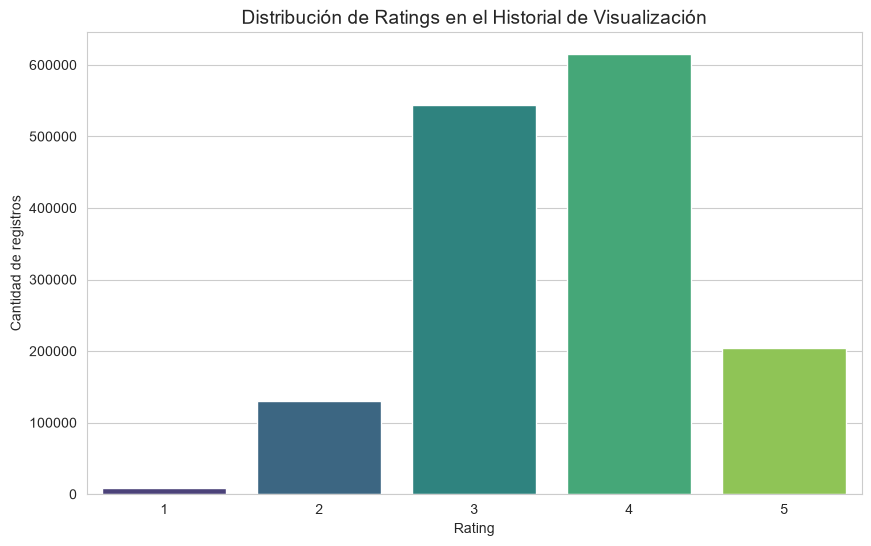

rating
1    0.55
2    8.66
3   36.21
4   40.94
5   13.63
Name: proportion, dtype: float64


In [17]:
# Gráfico 1: Distribución de ratings

plt.figure(figsize=(10, 6))
sns.countplot(data=df_viewing, x='rating', palette='viridis')
plt.title('Distribución de Ratings en el Historial de Visualización', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Cantidad de registros')
plt.show()

print(df_viewing['rating'].value_counts(normalize=True).sort_index() * 100)

C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\440316458.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, palette='viridis')


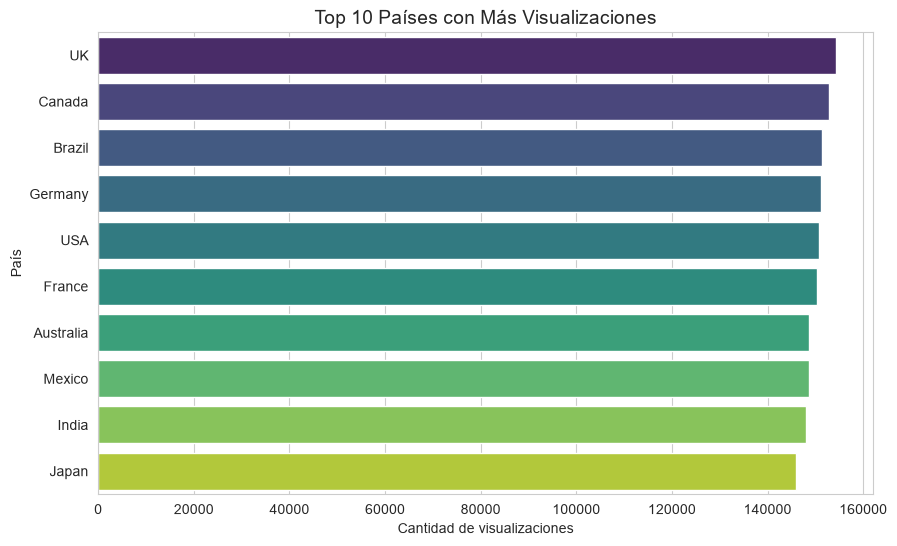

Country
UK           154376
Canada       152891
Brazil       151453
Germany      151257
USA          150732
France       150263
Australia    148675
Mexico       148638
India        148083
Japan        145990
Name: count, dtype: int64


In [18]:
# Gráfico 2: Visualizaciones por país

vh_pais = df_viewing.merge(df_users[['User_ID', 'Country']], left_on='user_id', right_on='User_ID', how='left')

top_paises = vh_pais['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_paises.values, y=top_paises.index, palette='viridis')
plt.title('Top 10 Países con Más Visualizaciones', fontsize=14)
plt.xlabel('Cantidad de visualizaciones')
plt.ylabel('País')
plt.show()

print(top_paises)

C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\1437812655.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=horas_por_momento.index, y=horas_por_momento.values, palette='viridis')


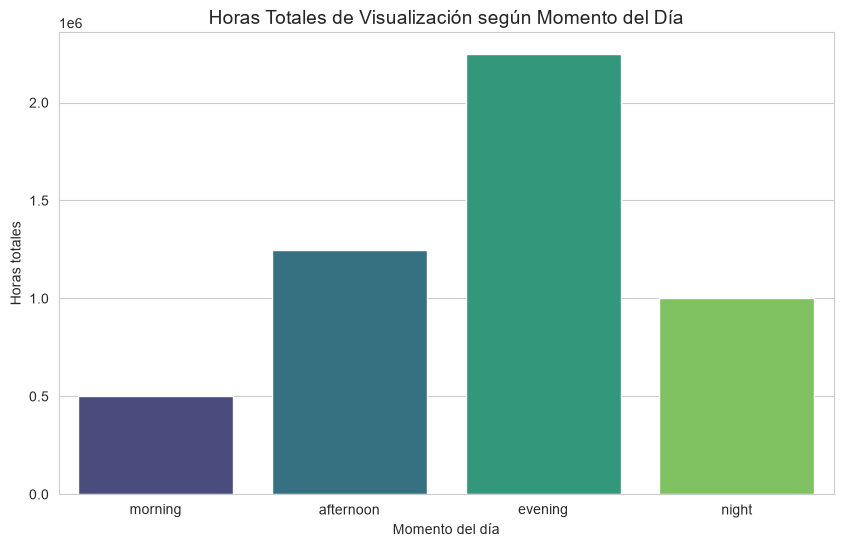

time_of_day
morning       501,296.67
afternoon   1,244,871.38
evening     2,246,592.85
night       1,000,113.35
Name: watch_duration_minutes, dtype: float64


In [19]:
# Gráfico 3: Horas de visualización según momento del día


horas_por_momento = df_viewing.groupby('time_of_day')['watch_duration_minutes'].sum() / 60
orden = ['morning', 'afternoon', 'evening', 'night']
horas_por_momento = horas_por_momento.reindex(orden)

plt.figure(figsize=(10, 6))
sns.barplot(x=horas_por_momento.index, y=horas_por_momento.values, palette='viridis')
plt.title('Horas Totales de Visualización según Momento del Día', fontsize=14)
plt.xlabel('Momento del día')
plt.ylabel('Horas totales')
plt.show()

print(horas_por_momento)

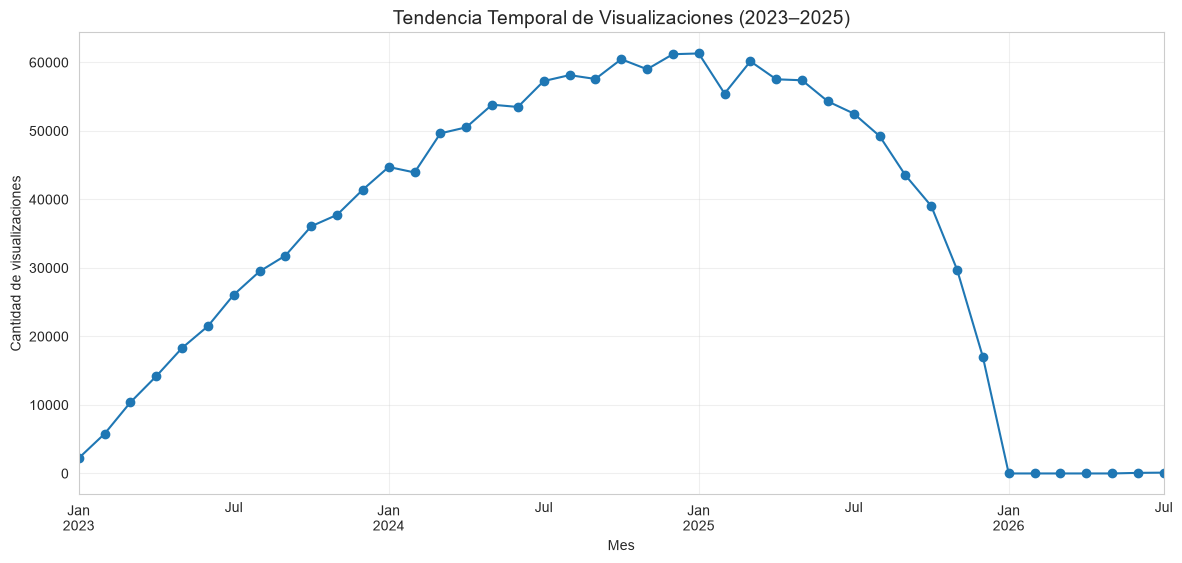

watch_date
2023-01-31     2234
2023-02-28     5786
2023-03-31    10380
2023-04-30    14193
2023-05-31    18314
2023-06-30    21499
2023-07-31    26083
2023-08-31    29491
2023-09-30    31801
2023-10-31    36080
2023-11-30    37750
2023-12-31    41437
2024-01-31    44737
2024-02-29    43936
2024-03-31    49643
2024-04-30    50525
2024-05-31    53829
2024-06-30    53497
2024-07-31    57277
2024-08-31    58144
2024-09-30    57582
2024-10-31    60467
2024-11-30    59001
2024-12-31    61197
2025-01-31    61307
2025-02-28    55456
2025-03-31    60160
2025-04-30    57535
2025-05-31    57393
2025-06-30    54307
2025-07-31    52535
2025-08-31    49255
2025-09-30    43526
2025-10-31    39044
2025-11-30    29755
2025-12-31    16997
2026-01-31        0
2026-02-28        0
2026-03-31        0
2026-04-30        0
2026-05-31        0
2026-06-30       86
2026-07-31      119
Freq: ME, dtype: int64


In [20]:
# Gráfico 4: Tendencia temporal de visualizaciones

tendencia = df_viewing.set_index('watch_date').resample('ME').size()

plt.figure(figsize=(14, 6))
tendencia.plot(marker='o', color='#1f77b4')
plt.title('Tendencia Temporal de Visualizaciones (2023–2025)', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Cantidad de visualizaciones')
plt.grid(True, alpha=0.3)
plt.show()

print(tendencia)

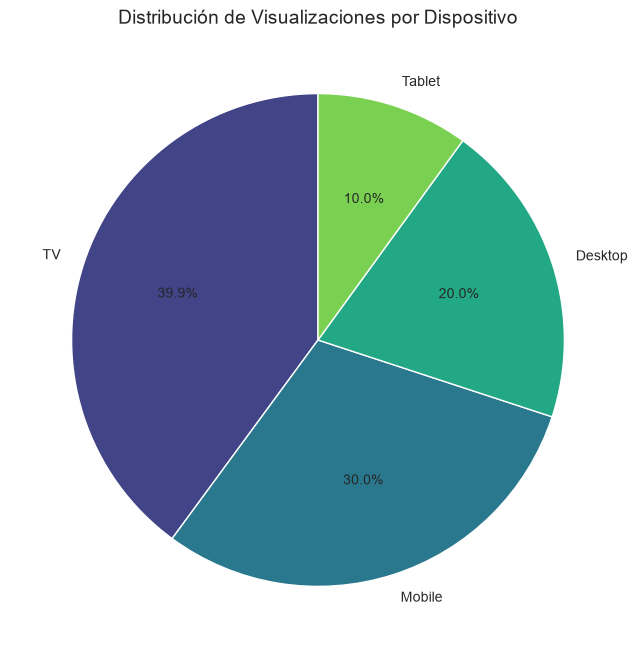

device
TV         599704
Mobile     451247
Desktop    301191
Tablet     150216
Name: count, dtype: int64


In [21]:
# Gráfico 5: Distribución de dispositivos


plt.figure(figsize=(8, 8))
device_counts = df_viewing['device'].value_counts()
plt.pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('viridis', len(device_counts)), startangle=90)
plt.title('Distribución de Visualizaciones por Dispositivo', fontsize=14)
plt.show()

print(device_counts)

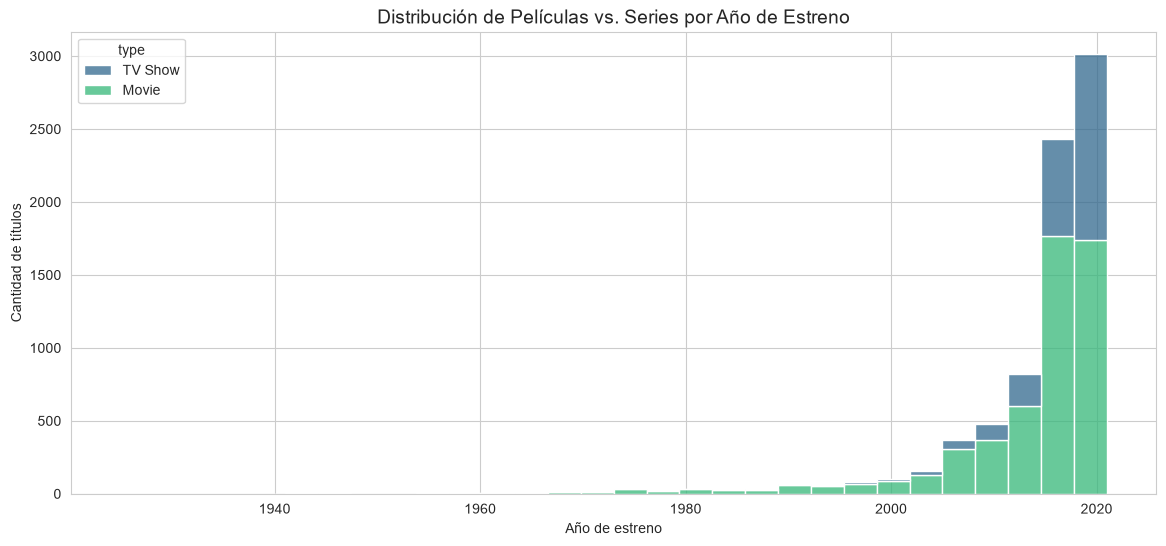

           count     mean  std      min      25%      50%      75%      max
type                                                                       
Movie   5,377.00 2,012.92 9.66 1,942.00 2,012.00 2,016.00 2,018.00 2,021.00
TV Show 2,410.00 2,016.19 5.66 1,925.00 2,015.00 2,018.00 2,019.00 2,021.00


In [22]:
# Gráfico 6: Películas vs. Series por año de estreno

plt.figure(figsize=(14, 6))
sns.histplot(data=df_catalog, x='release_year', hue='type', multiple='stack',
             palette='viridis', bins=30)
plt.title('Distribución de Películas vs. Series por Año de Estreno', fontsize=14)
plt.xlabel('Año de estreno')
plt.ylabel('Cantidad de títulos')
plt.show()

print(df_catalog.groupby('type')['release_year'].describe())

# **2. Perfilamiento de Usuarios**

Perfilamiento de Usuarios
Se va a analizar lo siguiente en este documento:
- Clústeres de usuarios según edad, horas de visualización, tipo de suscripción y género favorito (KMeans)
- Diferencias de consumo entre usuarios activos (active=1) e inactivos (active=0)
- Correlación entre variables demográficas y hábitos de visualización (rating promedio, género más visto, dispositivo preferido)

Según edad

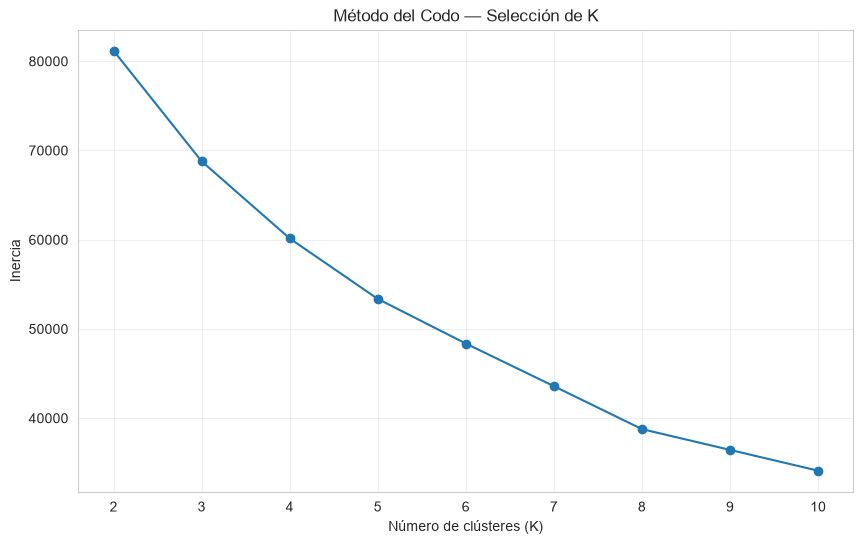

In [23]:
# Clustering con KMeans

from sklearn.preprocessing import LabelEncoder

df_cluster = df_users.copy()

# Codificar variables categóricas
le_sub = LabelEncoder()
le_genre = LabelEncoder()
df_cluster['Subscription_Type_enc'] = le_sub.fit_transform(df_cluster['Subscription_Type'])
df_cluster['Favorite_Genre_enc'] = le_genre.fit_transform(df_cluster['Favorite_Genre'])

# Variables para el clustering
features = ['Age', 'Watch_Time_Hours', 'Subscription_Type_enc', 'Favorite_Genre_enc']
X = df_cluster[features]

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Método del codo para elegir K
inercia = []
rango_k = range(2, 11)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o')
plt.title('Método del Codo — Selección de K')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Inercia')
plt.grid(True, alpha=0.3)
plt.show()

,n_usuarios,edad_promedio,horas_promedio,suscripcion_top,genero_top,pais_top
cluster,,,,,,
0,4972,46.00,313.10,Standard,Sci-Fi,India
1,4714,27.70,748.70,Basic,Horror,USA
2,5242,50.50,571.30,Standard,Action,Canada
3,5245,42.00,232.90,Basic,Action,USA
4,4827,65.90,664.80,Basic,Romance,Brazil


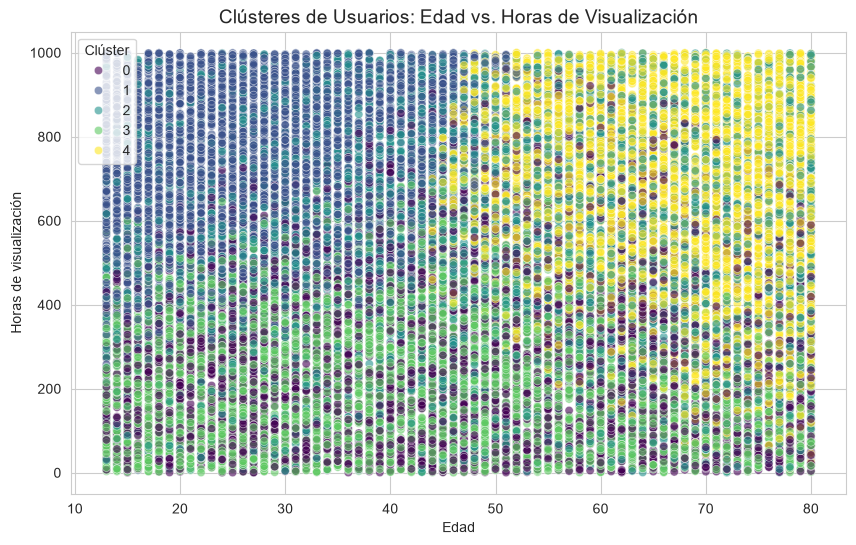

C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\3050808583.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster, x='cluster', y='Watch_Time_Hours', palette='viridis')


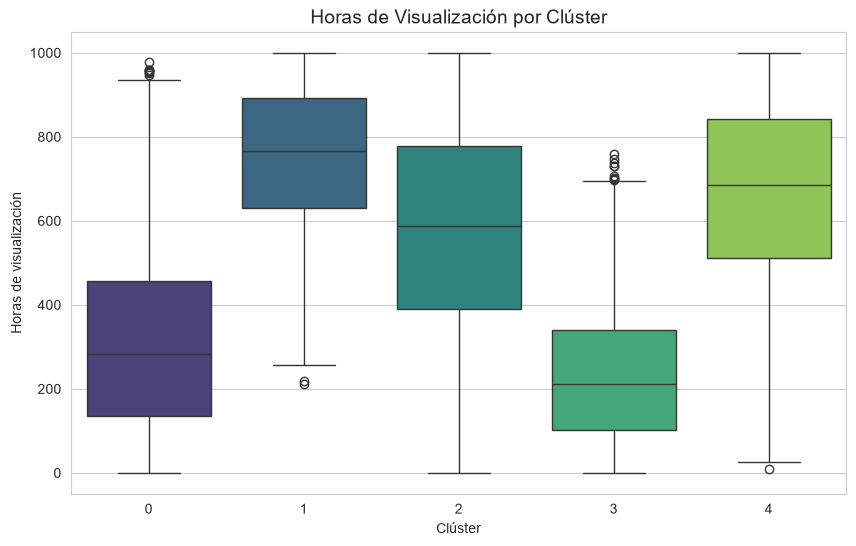

In [24]:
#PERFILAMIENTO DE USUARIOS — Clustering final (K=5)

K_OPTIMO = 5

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Caracterización de cada clúster (promedios de las variables originales)
resumen_clusters = df_cluster.groupby('cluster').agg(
    n_usuarios=('User_ID', 'count'),
    edad_promedio=('Age', 'mean'),
    horas_promedio=('Watch_Time_Hours', 'mean'),
    suscripcion_top=('Subscription_Type', lambda x: x.mode()[0]),
    genero_top=('Favorite_Genre', lambda x: x.mode()[0]),
    pais_top=('Country', lambda x: x.mode()[0])
).round(1)

display(resumen_clusters)

# Visualización: edad vs horas de visualización coloreado por clúster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='Age', y='Watch_Time_Hours', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Clústeres de Usuarios: Edad vs. Horas de Visualización', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Horas de visualización')
plt.legend(title='Clúster')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster, x='cluster', y='Watch_Time_Hours', palette='viridis')
plt.title('Horas de Visualización por Clúster', fontsize=14)
plt.xlabel('Clúster')
plt.ylabel('Horas de visualización')
plt.show()

Según el estado del usuario (Activo/Inactivo)

,n_usuarios,edad_promedio,horas_promedio,suscripcion_top,genero_top
active,,,,,
0,2047,46.30,501.00,Standard,Horror
1,22953,46.50,500.40,Premium,Documentary


C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\2866033583.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_users, x='active', y='Watch_Time_Hours', palette='viridis')


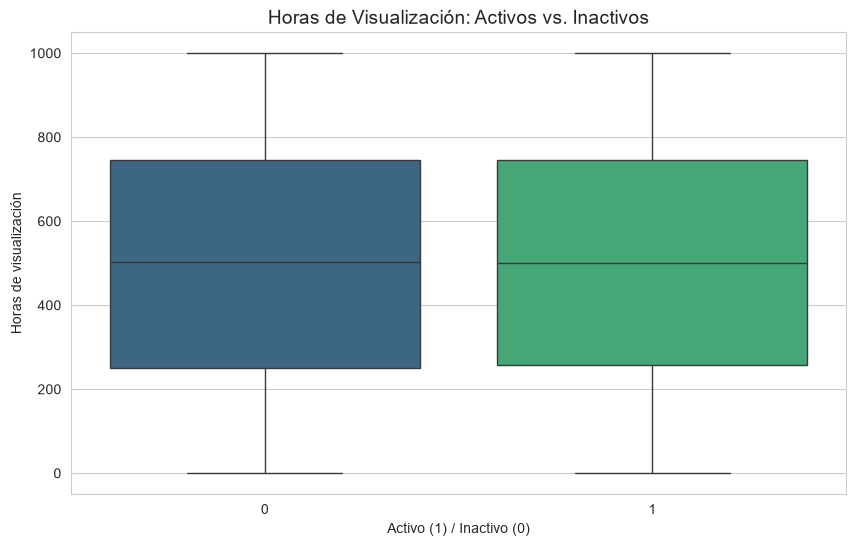

In [25]:
# Activos vs. Inactivos

comparacion_activos = df_users.groupby('active').agg(
    n_usuarios=('User_ID', 'count'),
    edad_promedio=('Age', 'mean'),
    horas_promedio=('Watch_Time_Hours', 'mean'),
    suscripcion_top=('Subscription_Type', lambda x: x.mode()[0]),
    genero_top=('Favorite_Genre', lambda x: x.mode()[0])
).round(1)

display(comparacion_activos)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_users, x='active', y='Watch_Time_Hours', palette='viridis')
plt.title('Horas de Visualización: Activos vs. Inactivos', fontsize=14)
plt.xlabel('Activo (1) / Inactivo (0)')
plt.ylabel('Horas de visualización')
plt.show()

Correlación demografía vs. hábitos

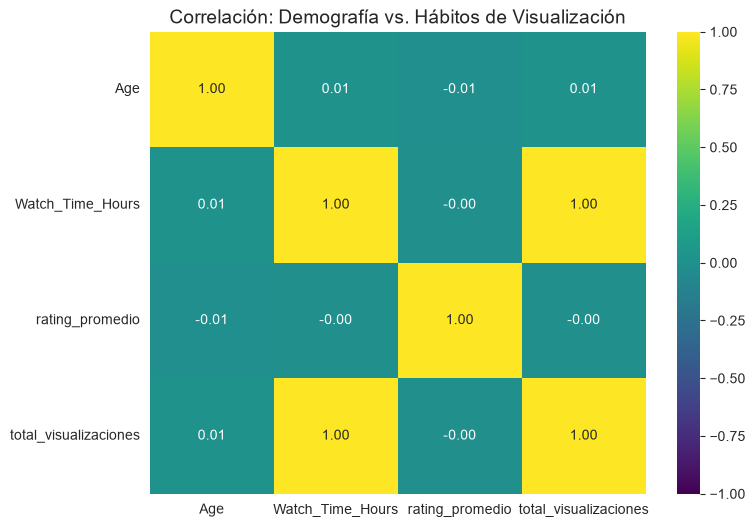

dispositivo_preferido,Desktop,Mobile,TV,Tablet
rango_edad,,,,
<25,215,941,3600,8
25-40,258,1104,4142,12
40-60,347,1563,5477,9
60+,341,1555,5420,8


In [26]:
# 7 Correlación demografía vs. hábitos

# Agregar hábitos de visualización por usuario
habitos_usuario = df_viewing.groupby('user_id').agg(
    rating_promedio=('rating', 'mean'),
    dispositivo_preferido=('device', lambda x: x.mode()[0]),
    horario_preferido=('time_of_day', lambda x: x.mode()[0]),
    total_visualizaciones=('show_id', 'count')
).reset_index()

# Unir con datos demográficos
usuarios_habitos = df_users.merge(habitos_usuario, left_on='User_ID', right_on='user_id', how='inner')

# Matriz de correlación entre variables numéricas
cols_numericas = ['Age', 'Watch_Time_Hours', 'rating_promedio', 'total_visualizaciones']
corr = usuarios_habitos[cols_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlación: Demografía vs. Hábitos de Visualización', fontsize=14)
plt.show()

# Dispositivo preferido según rango etario
usuarios_habitos['rango_edad'] = pd.cut(usuarios_habitos['Age'], bins=[0, 25, 40, 60, 100],
                                          labels=['<25', '25-40', '40-60', '60+'])
tabla_dispositivo = pd.crosstab(usuarios_habitos['rango_edad'], usuarios_habitos['dispositivo_preferido'])
display(tabla_dispositivo)

# **3. Análisis del Catálogo**

Se va a analizar lo siguiente en este documento:
- Distribución de películas vs. series por país y año de estreno
- Géneros, directores y actores más frecuentes
- Relación entre disponibilidad del catálogo (active) y patrones de consumo

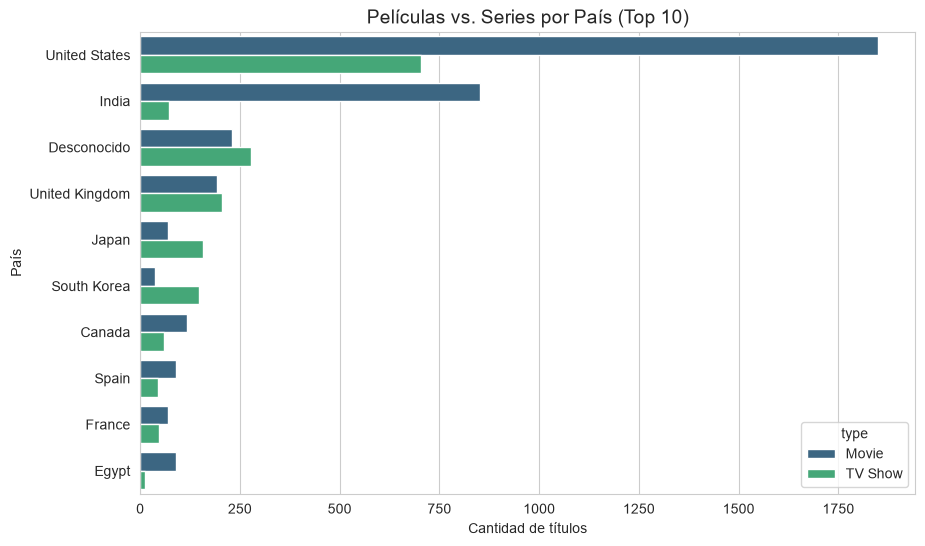

C:\Users\cilio\AppData\Local\Temp\ipykernel_27876\1151457480.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette='viridis')


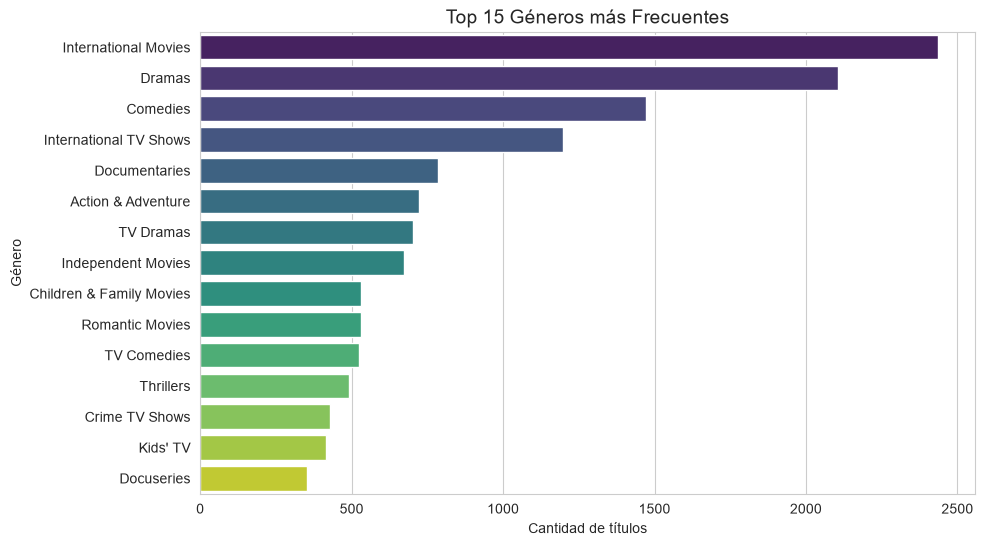

Top 10 directores:
director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Youssef Chahine           12
Martin Scorsese           12
Steven Spielberg          10
David Dhawan               9
Hakan Algül                8
Name: count, dtype: int64

Top 10 actores:
cast
Anupam Kher         42
Shah Rukh Khan      35
Om Puri             30
Naseeruddin Shah    30
Akshay Kumar        29
Takahiro Sakurai    29
Boman Irani         27
Amitabh Bachchan    27
Paresh Rawal        27
Yuki Kaji           27
Name: count, dtype: int64

Visualizaciones promedio según disponibilidad (active):
active
0   206.40
1   191.50
Name: veces_visto, dtype: float64


In [27]:
# ============================================================
#  ANÁLISIS DEL CATÁLOGO
# ============================================================

# --- 1. Películas vs. Series por país (top 10) ---
top_paises_catalogo = df_catalog['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.countplot(data=df_catalog[df_catalog['country'].isin(top_paises_catalogo.index)],
              y='country', hue='type', palette='viridis',
              order=top_paises_catalogo.index)
plt.title('Películas vs. Series por País (Top 10)', fontsize=14)
plt.xlabel('Cantidad de títulos')
plt.ylabel('País')
plt.show()

# --- 2. Géneros más frecuentes ---
generos_expandidos = df_catalog['genres'].str.split(', ').explode()
top_generos = generos_expandidos.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_generos.values, y=top_generos.index, palette='viridis')
plt.title('Top 15 Géneros más Frecuentes', fontsize=14)
plt.xlabel('Cantidad de títulos')
plt.ylabel('Género')
plt.show()

# --- 3. Directores más frecuentes (excluyendo 'Desconocido') ---
top_directores = df_catalog[df_catalog['director'] != 'Desconocido']['director'].value_counts().head(10)
print("Top 10 directores:")
print(top_directores)

# --- 4. Actores más frecuentes ---
actores_expandidos = df_catalog[df_catalog['cast'] != 'Desconocido']['cast'].str.split(', ').explode()
top_actores = actores_expandidos.value_counts().head(10)
print("\nTop 10 actores:")
print(top_actores)

# --- 5. Disponibilidad (active) vs. consumo real ---
consumo_por_titulo = df_viewing.groupby('show_id').size().reset_index(name='veces_visto')
catalogo_consumo = df_catalog.merge(consumo_por_titulo, on='show_id', how='left')
catalogo_consumo['veces_visto'] = catalogo_consumo['veces_visto'].fillna(0)

consumo_activo = catalogo_consumo.groupby('active')['veces_visto'].mean().round(1)
print("\nVisualizaciones promedio según disponibilidad (active):")
print(consumo_activo)

### ACTIVIDADES OPCIONALES — Nivel 1 (+0.5): dashboard exploratorio unificado

Panel integrado que consolida en una sola figura los hallazgos de las secciones
exploratorias anteriores, con seis visualizaciones interactivas (Plotly):
composición del catálogo por género y por tipo, distribución de calificaciones,
evolución temporal del consumo, perfil etario de los usuarios y títulos más
vistos.

Se ubica al cierre del análisis exploratorio porque integra los tres datasets
(catálogo, historial de visualización y usuarios), de modo que cada panel
resume una dimensión ya analizada individualmente en las secciones previas.

Todas las visualizaciones permiten inspección interactiva: valores exactos al
pasar el cursor, zoom sobre regiones de interés, activación y desactivación de
series, y exportación a imagen.

In [28]:
# ============================================================
# X ACTIVIDADES OPCIONALES — Nivel 1 (+0.5)
# Dashboard unificado: 6 visualizaciones interactivas en una figura
# ============================================================
# Panel integrado que resume el catálogo, el historial de visualización y el
# perfil de los usuarios en una sola vista. Todas las visualizaciones son
# interactivas (Plotly): permiten hover con datos exactos, zoom y exportación.

import plotly.graph_objects as go
from plotly.subplots import make_subplots

vh = df_viewing_full if 'df_viewing_full' in globals() else df_viewing
PALETA = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=("Top 10 géneros del catálogo",
                    "Distribución de calificaciones",
                    "Visualizaciones por mes",
                    "Tipo de contenido: catálogo vs. consumo",
                    "Edad de los usuarios",
                    "Top 10 títulos más vistos"),
    vertical_spacing=0.16, horizontal_spacing=0.10)

# --- 1. Top 10 géneros del catálogo ---
generos = (df_catalog['genres'].fillna('').str.split(',').explode()
           .str.strip().replace('', np.nan).dropna().value_counts().head(10))
fig.add_trace(go.Bar(x=generos.values[::-1], y=generos.index[::-1], orientation='h',
                     marker_color=PALETA[0],
                     hovertemplate='%{y}<br>%{x:,} títulos<extra></extra>'), row=1, col=1)

# --- 2. Distribución de calificaciones ---
ratings = vh['rating'].value_counts().sort_index()
fig.add_trace(go.Bar(x=ratings.index, y=ratings.values, marker_color=PALETA[1],
                     hovertemplate='Rating %{x}<br>%{y:,} registros<extra></extra>'),
              row=1, col=2)

# --- 3. Serie temporal de visualizaciones ---
por_mes = vh.set_index('watch_date').resample('ME').size()
fig.add_trace(go.Scatter(x=por_mes.index, y=por_mes.values, mode='lines',
                         line=dict(color=PALETA[2], width=2), fill='tozeroy',
                         hovertemplate='%{x|%b %Y}<br>%{y:,} visualizaciones<extra></extra>'),
              row=1, col=3)

# --- 4. Tipo de contenido: oferta vs. consumo ---
tipo_cat = df_catalog['type'].value_counts(normalize=True) * 100
tipo_vis = (vh[['show_id']].merge(df_catalog[['show_id', 'type']], on='show_id', how='left')
            ['type'].value_counts(normalize=True) * 100)
tipos = sorted(set(tipo_cat.index) | set(tipo_vis.index))
fig.add_trace(go.Bar(x=tipos, y=[tipo_cat.get(t, 0) for t in tipos], name='Catálogo',
                     marker_color=PALETA[0], legendgroup='t', showlegend=True,
                     hovertemplate='%{x} (catálogo)<br>%{y:.1f}%<extra></extra>'), row=2, col=1)
fig.add_trace(go.Bar(x=tipos, y=[tipo_vis.get(t, 0) for t in tipos], name='Consumo',
                     marker_color=PALETA[3], legendgroup='t', showlegend=True,
                     hovertemplate='%{x} (consumo)<br>%{y:.1f}%<extra></extra>'), row=2, col=1)

# --- 5. Distribución de edades ---
fig.add_trace(go.Histogram(x=df_users['Age'], nbinsx=30, marker_color=PALETA[4],
                           hovertemplate='%{x} años<br>%{y:,} usuarios<extra></extra>'),
              row=2, col=2)

# --- 6. Top 10 títulos más vistos ---
top_titulos = vh['show_id'].value_counts().head(10)
nombres = (df_catalog.set_index('show_id').reindex(top_titulos.index)['title']
           .fillna('(desconocido)').str.slice(0, 28))
fig.add_trace(go.Bar(x=top_titulos.values[::-1], y=nombres.values[::-1], orientation='h',
                     marker_color=PALETA[5],
                     hovertemplate='%{y}<br>%{x:,} visualizaciones<extra></extra>'),
              row=2, col=3)

# --- Ejes ---
fig.update_xaxes(title_text='Títulos', row=1, col=1)
fig.update_xaxes(title_text='Calificación', dtick=1, row=1, col=2)
fig.update_yaxes(title_text='Registros', row=1, col=2)
fig.update_yaxes(title_text='Visualizaciones', row=1, col=3)
fig.update_yaxes(title_text='% del total', row=2, col=1)
fig.update_xaxes(title_text='Edad', row=2, col=2)
fig.update_yaxes(title_text='Usuarios', row=2, col=2)
fig.update_xaxes(title_text='Visualizaciones', row=2, col=3)
fig.update_yaxes(tickfont=dict(size=9), row=2, col=3)
fig.update_yaxes(tickfont=dict(size=9), row=1, col=1)

fig.update_layout(
    title=dict(text='<b>Dashboard exploratorio — Netflix</b><br>'
                    f'<sup>{len(vh):,} visualizaciones | {df_users["User_ID"].nunique():,} usuarios | '
                    f'{len(df_catalog):,} títulos</sup>', x=0.5, y=0.97),
    height=800, margin=dict(t=140), template='plotly_white', barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=-0.09, xanchor='center', x=0.16))
fig.update_annotations(font_size=12)
fig.show()

print("Dashboard generado: 6 visualizaciones interactivas en una sola figura.")
print("Interacciones disponibles: hover con valores exactos, zoom, pan, "
      "selección de series y exportación a PNG.")

Dashboard generado: 6 visualizaciones interactivas en una sola figura.
Interacciones disponibles: hover con valores exactos, zoom, pan, selección de series y exportación a PNG.


# 4. Algoritmo de **Recomendación**

Se va a construir lo siguiente en este documento:
- Matriz usuario-item a partir del historial limpio
- Filtrado Colaborativo Item-Based (similitud coseno + promedio ponderado)
- Content-Based Filtering con TF-IDF sobre géneros (y fallback para cold-start)
- Reglas de negocio (popularidad, tipo de contenido, actualidad, exclusión de ya vistos/no disponibles)
- Blender lineal para combinar los 3 componentes
- Función final recomendar(user_id, n=10, min_rating=3)

In [31]:
# ============================================================
# 4. ALGORITMO DE RECOMENDACIÓN — Registro de títulos ya consumidos
# ============================================================
# El enunciado exige que el playlist NO contenga títulos que el usuario ya
# consumió, y descartar los vistos completamente (completed=True o
# pct_watched=100). Aquí se aplica un criterio más estricto: se excluye TODO
# lo consumido, calificado o no, lo cual cubre ambos requisitos.

df_vistos = df_vistos_raw.dropna(subset=['user_id', 'show_id']).copy()

# Solo IDs válidos (mismo criterio de integridad que la limpieza)
df_vistos = df_vistos[
    df_vistos['user_id'].isin(df_users['User_ID']) &
    df_vistos['show_id'].isin(df_catalog['show_id'])
]
df_vistos['user_id'] = df_vistos['user_id'].astype(int)

# Evidencia para el informe: cuántos cumplen el criterio explícito del enunciado
if {'completed', 'pct_watched'}.issubset(df_vistos.columns):
    completados = ((df_vistos['completed'] == True) | (df_vistos['pct_watched'] >= 100)).sum()
    print(f"Títulos consumidos completamente (completed=True o pct_watched=100): {completados}")

# Se refuerza con el historial limpio por si el orden de ejecución cambia
df_vistos = pd.concat([
    df_vistos[['user_id', 'show_id']],
    df_viewing[['user_id', 'show_id']]
], ignore_index=True).drop_duplicates()

VISTOS_POR_USUARIO = df_vistos.groupby('user_id')['show_id'].apply(set).to_dict()

def obtener_vistos(user_id):
    """Conjunto de show_id que el usuario ya consumió (con o sin rating)."""
    return VISTOS_POR_USUARIO.get(user_id, set())

print("Usuarios con historial de consumo registrado:", len(VISTOS_POR_USUARIO))
print("Promedio de títulos consumidos por usuario:",
      round(df_vistos.groupby('user_id').size().mean(), 2))
print("Títulos calificados (en la matriz):", len(df_viewing))
print("Títulos consumidos totales (base de exclusión):", len(df_vistos))

Títulos consumidos completamente (completed=True o pct_watched=100): 523662
Usuarios con historial de consumo registrado: 25000
Promedio de títulos consumidos por usuario: 59.1
Títulos calificados (en la matriz): 1502358
Títulos consumidos totales (base de exclusión): 1477445


In [32]:
# ============================================================
# 4.2 ALGORITMO DE RECOMENDACIÓN — Matriz Usuario-Item (CF)
# ============================================================

# Matriz usuario-item: filas = usuarios, columnas = shows, valores = rating
user_item_matrix = df_viewing.pivot_table(index='user_id', columns='show_id', values='rating')

print("Dimensiones de la matriz usuario-item:", user_item_matrix.shape)
print(f"Sparsity (proporción de celdas vacías): {user_item_matrix.isna().mean().mean() * 100:.2f}%")

display(user_item_matrix.iloc[:5, :5])

Dimensiones de la matriz usuario-item: (25000, 7787)
Sparsity (proporción de celdas vacías): 99.24%


show_id,s1,s10,s100,s1000,s1001
user_id,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


In [33]:
# ============================================================
# 4.3 ALGORITMO DE RECOMENDACIÓN — Normalización y Similitud entre Ítems
# ============================================================
# Versión optimizada con matriz dispersa (scipy.sparse): la matriz usuario-item
# es >99% vacía, así que operar en denso desperdicia memoria y CPU. Esto baja
# el tiempo de minutos a segundos.

from scipy.sparse import csr_matrix

# Media de rating por usuario (se usa para centrar Y la reutilizan las celdas
# siguientes del algoritmo, p.ej. la predicción CF de la celda 4.4)
user_means = df_viewing.groupby('user_id')['rating'].mean()

# Centrar ratings por usuario ANTES de construir la matriz (evita crear la matriz densa)
df_temp = df_viewing[['user_id', 'show_id', 'rating']].copy()
df_temp['rating_centered'] = df_temp['rating'] - df_temp['user_id'].map(user_means)

# Codificar usuarios y shows como índices numéricos
user_cat = df_temp['user_id'].astype('category')
show_cat = df_temp['show_id'].astype('category')

# Construir matriz dispersa directamente (solo guarda los valores reales)
sparse_matrix = csr_matrix(
    (df_temp['rating_centered'], (user_cat.cat.codes, show_cat.cat.codes)),
    shape=(len(user_cat.cat.categories), len(show_cat.cat.categories))
)

# Similitud coseno entre ítems, sobre la matriz dispersa (mucho más rápido)
item_similarity = cosine_similarity(sparse_matrix.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=show_cat.cat.categories,
    columns=show_cat.cat.categories
)

# Reconstruir user_item_matrix para que el resto del notebook (CF, recomendar(), etc.)
# lo siga usando exactamente igual que antes
user_item_matrix = df_viewing.pivot_table(index='user_id', columns='show_id', values='rating')

print("Dimensiones de la matriz de similitud entre ítems:", item_similarity_df.shape)

show_ejemplo = item_similarity_df.columns[0]
print(f"\nTítulos más similares a '{show_ejemplo}':")
print(item_similarity_df[show_ejemplo].sort_values(ascending=False).head(6))


Dimensiones de la matriz de similitud entre ítems: (7787, 7787)

Títulos más similares a 's1':
s1      1.00
s1129   0.05
s7662   0.04
s1853   0.04
s667    0.03
s1203   0.03
Name: s1, dtype: float64


In [34]:
# ============================================================
# 4.4 ALGORITMO DE RECOMENDACIÓN — Predicción CF (promedio ponderado)
# ============================================================
# Mejoras respecto a la versión inicial:
#  1) La predicción se hace sobre ratings CENTRADOS (desviación respecto a la
#     media del usuario) y luego se devuelve la media: evita que todas las
#     predicciones saturen en 5.00.
#  2) Factor de confianza por soporte: una predicción sostenida por un solo
#     vecino con similitud 0.03 pesa mucho menos que una sostenida por 20.
#  3) Cálculo vectorizado: todas las predicciones de un usuario en una sola
#     operación matricial, en vez de un bucle sobre los ~7.787 títulos.

K_VECINOS = 20         # vecinos más similares considerados
PERCENTIL_SHRINK = 90  # el soporte en este percentil recibe confianza 0.5


def predecir_ratings_cf(user_id, k=K_VECINOS, lam=None):
    """Predice el rating de TODOS los títulos para un usuario.

    Fórmula:  pred = media_u + [Σ(sim · (rating − media_u)) / Σ sim] · confianza
    donde     confianza = Σ sim / (Σ sim + lambda)

    Devuelve un DataFrame indexado por show_id con:
      - prediccion : rating estimado (1-5)
      - n_vecinos  : cuántos vecinos sostienen la predicción
      - suma_sim   : soporte total (suma de similitudes usadas)
    """
    columnas = ['prediccion', 'n_vecinos', 'suma_sim']

    if user_id not in user_item_matrix.index:
        return pd.DataFrame(columns=columnas)

    calificados = user_item_matrix.loc[user_id].dropna()
    if calificados.empty:
        return pd.DataFrame(columns=columnas)

    media_u = user_means.loc[user_id]
    desviaciones = (calificados - media_u).to_numpy()

    # Similitudes: (todos los títulos) x (títulos que el usuario calificó)
    S = item_similarity_df.loc[:, calificados.index].to_numpy(copy=True)
    S[S <= 0] = 0.0  # solo vecinos positivos; los negativos meten ruido

    # Conservar únicamente los k vecinos más similares por título
    if S.shape[1] > k:
        menores = np.argpartition(S, -k, axis=1)[:, :-k]
        np.put_along_axis(S, menores, 0.0, axis=1)

    suma_sim = S.sum(axis=1)
    n_vecinos = (S > 0).sum(axis=1)

    numerador = S @ desviaciones
    desviacion_estimada = np.divide(numerador, suma_sim,
                                    out=np.zeros_like(numerador), where=suma_sim > 0)

    if lam is None:
        soporte_positivo = suma_sim[suma_sim > 0]
        lam = np.percentile(soporte_positivo, PERCENTIL_SHRINK) if soporte_positivo.size else 1.0

    confianza = suma_sim / (suma_sim + lam)
    prediccion = np.clip(media_u + desviacion_estimada * confianza, 1, 5)

    resultado = pd.DataFrame(
        {'prediccion': prediccion, 'n_vecinos': n_vecinos, 'suma_sim': suma_sim},
        index=item_similarity_df.index
    )
    resultado.loc[suma_sim == 0, 'prediccion'] = np.nan  # sin vecinos = sin predicción
    return resultado


def predecir_rating_cf(user_id, show_id, k=K_VECINOS):
    """Predicción CF para un único título (versión explicativa, misma fórmula)."""
    preds = predecir_ratings_cf(user_id, k=k)
    if preds.empty or show_id not in preds.index:
        return np.nan
    return preds.loc[show_id, 'prediccion']


def obtener_candidatos_cf(user_id, n=10, k=K_VECINOS):
    """Devuelve los n títulos con mayor predicción CF, excluyendo los ya consumidos."""
    preds = predecir_ratings_cf(user_id, k=k)
    if preds.empty:
        return pd.Series(dtype=float)

    vistos_usuario = obtener_vistos(user_id)
    preds = preds.drop(index=[s for s in vistos_usuario if s in preds.index])
    preds = preds.dropna(subset=['prediccion'])

    return preds.sort_values('prediccion', ascending=False)['prediccion'].head(n)


# --- Prueba y diagnóstico ---
usuario_prueba = user_item_matrix.index[0]
detalle = predecir_ratings_cf(usuario_prueba)

print(f"Media de rating del usuario {usuario_prueba}: {user_means.loc[usuario_prueba]:.2f}")
print("\nSoporte (suma de similitudes) sobre todo el catálogo:")
print(detalle['suma_sim'].describe(percentiles=[.5, .9, .99]).round(3))

top_cf = obtener_candidatos_cf(usuario_prueba, n=10)
print(f"\nCandidatos CF para el usuario {usuario_prueba}:")
print(top_cf.round(3))
print("\nSoporte del top 10 (cuántos vecinos sostienen cada predicción):")
print(detalle.loc[top_cf.index].round(3))

soporte_pos = detalle['suma_sim'][detalle['suma_sim'] > 0]
lam_usado = np.percentile(soporte_pos, PERCENTIL_SHRINK)
print(f"\nλ calibrado (percentil {PERCENTIL_SHRINK} del soporte positivo): {lam_usado:.4f}")
print(f"Confianza de una predicción con soporte 0.10: {0.10 / (0.10 + lam_usado):.2f}")
print(f"Confianza de una predicción con soporte 0.02: {0.02 / (0.02 + lam_usado):.2f}")

Media de rating del usuario 1: 3.70

Soporte (suma de similitudes) sobre todo el catálogo:
count   7,787.00
mean        0.02
std         0.04
min         0.00
50%         0.02
90%         0.04
99%         0.07
max         1.05
Name: suma_sim, dtype: float64

Candidatos CF para el usuario 1:
s4578   4.62
s7047   4.54
s6218   4.51
s3537   4.42
s4536   4.42
s5145   4.40
s1423   4.40
s5775   4.40
s3921   4.39
s1804   4.38
Name: prediccion, dtype: float64

Soporte del top 10 (cuántos vecinos sostienen cada predicción):
       prediccion  n_vecinos  suma_sim
s4578        4.62          1      0.10
s7047        4.54          2      0.08
s6218        4.51          2      0.09
s3537        4.42          2      0.06
s4536        4.42          4      0.07
s5145        4.40          3      0.07
s1423        4.40          1      0.05
s5775        4.40          2      0.05
s3921        4.39          3      0.10
s1804        4.38          1      0.05

λ calibrado (percentil 90 del soporte positivo): 0

In [35]:
# ============================================================
# 4.5 ALGORITMO DE RECOMENDACIÓN — Content-Based Filtering (TF-IDF)
# ============================================================
# Cada género se trata como UN token completo (separado por comas), no como
# palabras sueltas. Con el tokenizador por defecto, "TV Dramas" e
# "International TV Shows" compartían los tokens "tv" y "shows" e inflaban la
# similitud entre géneros no relacionados. El diagnóstico 10.4 mostró que la
# continuidad de género es la principal señal de preferencia del dataset
# (ratio 2.14), por lo que la precisión de este componente es determinante.

def _tokenizar_generos(texto):
    return [g.strip() for g in str(texto).split(',') if g.strip()]


tfidf = TfidfVectorizer(tokenizer=_tokenizar_generos, token_pattern=None, lowercase=True)
tfidf_matrix = tfidf.fit_transform(df_catalog['genres'].fillna(''))

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=df_catalog['show_id'],
    columns=tfidf.get_feature_names_out()
)

print("Dimensiones de la matriz TF-IDF:", tfidf_df.shape)
print("Géneros reconocidos como token único:", len(tfidf.get_feature_names_out()))
print("Ejemplos:", list(tfidf.get_feature_names_out())[:8])


def obtener_perfil_contenido(user_id, min_rating=3):
    """Perfil de contenido del usuario: promedio de los vectores TF-IDF de los
    títulos que vio con rating >= min_rating."""
    if user_id not in user_item_matrix.index:
        return None

    ratings_usuario = user_item_matrix.loc[user_id].dropna()
    titulos_gustados = ratings_usuario[ratings_usuario >= min_rating].index
    titulos_gustados = [t for t in titulos_gustados if t in tfidf_df.index]

    if len(titulos_gustados) == 0:
        return None

    return tfidf_df.loc[titulos_gustados].mean(axis=0)


def obtener_candidatos_cb(user_id, n=10, min_rating=3):
    """Devuelve los n títulos más similares al perfil de contenido del usuario,
    excluyendo los ya consumidos. Es el fallback de cold-start.

    Con solo 42 géneros, muchos títulos comparten combinación exacta y por lo
    tanto vector TF-IDF idéntico: la similitud coseno no puede distinguirlos.
    El empate se resuelve por popularidad, criterio respaldado por la evaluación
    10.2 (la línea base de popularidad resultó competitiva) y por el diagnóstico
    10.4 (continuidad de género con ratio 2.14).
    """
    perfil = obtener_perfil_contenido(user_id, min_rating=min_rating)

    if perfil is None:
        return pd.Series(dtype=float)

    similitudes = pd.Series(
        cosine_similarity([perfil.values], tfidf_df.values)[0], index=tfidf_df.index)

    vistos_usuario = obtener_vistos(user_id)
    similitudes = similitudes.drop(index=[v for v in vistos_usuario if v in similitudes.index])

    pop = (POPULARIDAD_GLOBAL if 'POPULARIDAD_GLOBAL' in globals()
           else df_viewing['show_id'].value_counts())

    orden = pd.DataFrame({'sim': similitudes,
                          'pop': pop.reindex(similitudes.index).fillna(0)})
    orden = orden.sort_values(['sim', 'pop'], ascending=[False, False])

    return orden['sim'].head(n)


# --- Prueba y diagnóstico de poder discriminante ---
usuario_prueba = user_item_matrix.index[0]
perfil_p = obtener_perfil_contenido(usuario_prueba)

if perfil_p is not None:
    sims = pd.Series(cosine_similarity([perfil_p.values], tfidf_df.values)[0], index=tfidf_df.index)
    print(f"\nSimilitud del perfil del usuario {usuario_prueba} contra todo el catálogo:")
    print(sims.describe(percentiles=[.5, .9, .99]).round(4))
    print(f"Valores distintos entre los 50 mejores: {sims.nlargest(50).round(4).nunique()} / 50")
    print(f"\nGéneros dominantes del perfil: {perfil_p.nlargest(5).round(3).to_dict()}")

print(f"\nCandidatos Content-Based para el usuario {usuario_prueba}:")
print(obtener_candidatos_cb(usuario_prueba, n=10).round(4))

Dimensiones de la matriz TF-IDF: (7787, 42)
Géneros reconocidos como token único: 42
Ejemplos: ['action & adventure', 'anime features', 'anime series', 'british tv shows', 'children & family movies', 'classic & cult tv', 'classic movies', 'comedies']

Similitud del perfil del usuario 1 contra todo el catálogo:
count   7,787.00
mean        0.26
std         0.20
min         0.00
50%         0.24
90%         0.57
99%         0.69
max         0.73
dtype: float64
Valores distintos entre los 50 mejores: 2 / 50

Géneros dominantes del perfil: {'dramas': 0.213, 'international movies': 0.194, 'children & family movies': 0.187, 'thrillers': 0.164, 'docuseries': 0.111}

Candidatos Content-Based para el usuario 1:
show_id
s1256   0.73
s6174   0.73
s6800   0.73
s5242   0.73
s1738   0.73
s2463   0.73
s6007   0.73
s2109   0.73
s6369   0.69
s4753   0.69
Name: sim, dtype: float64


In [36]:
# ============================================================
# 4.6 ALGORITMO DE RECOMENDACIÓN — Reglas de Negocio
# ============================================================

def calcular_score_reglas(user_id, candidatos):
    """Calcula un score de reglas de negocio (0-1) para una lista de show_ids,
    combinando: popularidad en el país del usuario y preferencia de tipo
    (Movie vs TV Show) según su historial de consumo."""

    candidatos = list(candidatos)
    scores = pd.Series(0.0, index=candidatos)

    if len(candidatos) == 0:
        return scores

    # --- Factor 1: Popularidad en el país del usuario ---
    if user_id in df_users['User_ID'].values:
        pais_usuario = df_users.loc[df_users['User_ID'] == user_id, 'Country'].values[0]

        # Se usa la tabla precalculada por país si está disponible: recorrer 1.5M
        # filas en cada llamada haría inviable la evaluación masiva del punto 10.
        popularidad_pais = (POPULARIDAD_POR_PAIS.get(pais_usuario)
                            if 'POPULARIDAD_POR_PAIS' in globals() else None)
        if popularidad_pais is None:
            usuarios_mismo_pais = df_users.loc[df_users['Country'] == pais_usuario, 'User_ID']
            popularidad_pais = (df_viewing[df_viewing['user_id'].isin(usuarios_mismo_pais)]
                                .groupby('show_id').size())

        pop_candidatos = popularidad_pais.reindex(candidatos).fillna(0)

        if pop_candidatos.max() > 0:
            pop_normalizada = pop_candidatos / pop_candidatos.max()
        else:
            pop_normalizada = pop_candidatos

        scores += pop_normalizada * 0.5

    # --- Factor 2: Preferencia de tipo (Movie vs TV Show) ---
    vistos_usuario = obtener_vistos(user_id)
    tipos_vistos = df_catalog[df_catalog['show_id'].isin(vistos_usuario)]['type']
    proporcion_movie = (tipos_vistos == 'Movie').mean() if len(tipos_vistos) > 0 else 0.5

    tipos_candidatos = df_catalog.set_index('show_id').reindex(candidatos)['type']
    pref_tipo = tipos_candidatos.apply(
        lambda t: proporcion_movie if t == 'Movie' else (1 - proporcion_movie)
    ).fillna(0.5)
    scores += pref_tipo.values * 0.5

    return scores


# Prueba con los candidatos que ya generó el CF
candidatos_prueba = obtener_candidatos_cf(usuario_prueba, n=10).index
print("Score de reglas de negocio para los candidatos CF:")
print(calcular_score_reglas(usuario_prueba, candidatos_prueba))

Score de reglas de negocio para los candidatos CF:
s4578   0.48
s7047   0.13
s6218   0.66
s3537   0.15
s4536   0.90
s5145   0.44
s1423   0.44
s5775   0.69
s3921   0.82
s1804   0.48
dtype: float64


In [37]:
# ============================================================
# 4.7 ALGORITMO — Fallback para usuarios sin ningún historial
# ============================================================

def obtener_candidatos_fallback(user_id, n=10):
    """Último nivel de fallback: usuarios sin historial y por lo tanto sin
    perfil de contenido posible. Usa el género favorito declarado por el
    usuario + popularidad general del catálogo disponible."""

    catalogo_activo = df_catalog[df_catalog['active'] == 1]
    popularidad_general = (POPULARIDAD_GLOBAL if 'POPULARIDAD_GLOBAL' in globals()
                           else df_viewing['show_id'].value_counts())

    def _rankear(shows):
        cand = popularidad_general.reindex(shows).fillna(0).sort_values(ascending=False).head(n)
        return cand / cand.max() if cand.max() > 0 else cand + 1.0

    info_usuario = df_users[df_users['User_ID'] == user_id]
    genero_favorito = info_usuario['Favorite_Genre'].values[0] if not info_usuario.empty else None

    if pd.isna(genero_favorito) or not genero_favorito:
        return _rankear(catalogo_activo['show_id'])

    coincide_genero = catalogo_activo.loc[
        catalogo_activo['genres'].str.contains(str(genero_favorito), case=False,
                                               na=False, regex=False), 'show_id'
    ]

    if len(coincide_genero) == 0:
        return _rankear(catalogo_activo['show_id'])

    return _rankear(coincide_genero)

In [38]:
# ============================================================
# 4.8 ALGORITMO DE RECOMENDACIÓN — Blending y Función Final
# ============================================================
# Blender lineal: score_total = α·CF + β·CB + γ·Reglas
#
# PESOS CALIBRADOS EMPÍRICAMENTE (celda 10.5): grid search de 66 combinaciones
# con split interno train 2023 / validación 2024, dejando 2025 intacto para la
# evaluación final. Precision@10 sobre validación:
#
#   Solo CF     (1/0/0) : 0.0023   <- por debajo del azar (0.0029)
#   Solo Reglas (0/0/1) : 0.0178
#   Solo CB     (0/1/0) : 0.0193
#   Óptimo    (.1/.8/.1): 0.0211
#   Elegido   (.2/.6/.2): 0.0205   <- centro de la meseta, dentro del ±0.0014
#   Inicial   (.5/.3/.2): 0.0153
#
# Justificación: el diagnóstico 10.4 mostró que los ratings de este dataset no
# contienen criterio personal (efecto usuario ratio 0.98), por lo que el
# filtrado colaborativo predice poco más que ruido alrededor de la media. La
# señal de preferencia está en los géneros consumidos (continuidad train-test
# ratio 2.14), que es lo que captura el Content-Based: de ahí β = 0.6.
# α y γ se mantienen en 0.2 porque la mezcla supera a TODOS los componentes
# puros (0.0205 > 0.0193 del mejor individual): aun siendo débiles, CF y reglas
# aportan desempate. Se elige el centro de la meseta (β entre 0.6 y 0.9) en
# lugar del máximo puntual, para no sobreajustar a la muestra de validación.

ALPHA = 0.2
BETA = 0.6
GAMMA = 0.2


def _normalizar(serie):
    """Escala min-max al rango 0-1 dentro del pool de candidatos.
    Si todos los valores son iguales devuelve 0.5: ese componente no aporta
    información para desempatar, pero tampoco castiga a ningún candidato."""
    if len(serie) == 0:
        return serie
    minimo, maximo = serie.min(), serie.max()
    if not np.isfinite(minimo) or not np.isfinite(maximo) or maximo == minimo:
        return pd.Series(0.5, index=serie.index)
    return (serie - minimo) / (maximo - minimo)


def calcular_componentes(user_id, n=10, min_rating=3, k=K_VECINOS):
    """Calcula los tres componentes del sistema híbrido para un usuario.

    Devuelve (comp, ctx):
      comp : DataFrame indexado por show_id con los valores crudos
             (cf_raw, cb_raw, rules_raw), los normalizados (cf_n, cb_n, rules_n)
             y el soporte del CF (n_vecinos).
      ctx  : diccionario con el contexto del usuario (cold-start, media de
             rating, género dominante del perfil, datos demográficos).
    """
    # --- 1. Historial y detección de cold-start ---
    n_historial = user_item_matrix.loc[user_id].notna().sum() if user_id in user_item_matrix.index else 0
    es_cold_start = n_historial < 3

    vistos_usuario = obtener_vistos(user_id)
    disponibles = set(df_catalog.loc[df_catalog['active'] == 1, 'show_id'])

    # --- 2. Pool de candidatos ---
    candidatos_cb = obtener_candidatos_cb(user_id, n=n * 5, min_rating=min_rating)

    if es_cold_start:
        if candidatos_cb.empty:
            candidatos_cb = obtener_candidatos_fallback(user_id, n=n * 5)
        pool = list(candidatos_cb.index)
    else:
        candidatos_cf = obtener_candidatos_cf(user_id, n=n * 5, k=k)
        pool = list(dict.fromkeys(list(candidatos_cf.index) + list(candidatos_cb.index)))

    # Exclusiones ANTES de puntuar: no disponibles y ya consumidos
    pool = [c for c in pool if c in disponibles and c not in vistos_usuario]

    # Garantía de al menos n recomendaciones: completar con popularidad
    if len(pool) < n:
        extra = obtener_candidatos_fallback(user_id, n=n * 5)
        for s in extra.index:
            if s in disponibles and s not in vistos_usuario and s not in pool:
                pool.append(s)

    # --- Contexto del usuario (para las justificaciones) ---
    info_usuario = df_users[df_users['User_ID'] == user_id]
    media_u = user_means.loc[user_id] if user_id in user_means.index else df_viewing['rating'].mean()

    genero_top, n_genero_top, n_gustados = "N/D", 0, 0
    if user_id in user_item_matrix.index:
        ratings_u = user_item_matrix.loc[user_id].dropna()
        gustados = ratings_u[ratings_u >= min_rating].index
        n_gustados = len(gustados)
        generos_perfil = (df_catalog[df_catalog['show_id'].isin(gustados)]['genres']
                          .str.split(',').explode().str.strip())
        if len(generos_perfil) > 0:
            conteo_generos = generos_perfil.value_counts()
            genero_top = conteo_generos.index[0]
            n_genero_top = int(conteo_generos.iloc[0])

    ctx = {
        'es_cold_start': es_cold_start,
        'n_historial': int(n_historial),
        'media_u': float(media_u),
        'genero_top': genero_top,
        'n_genero_top': n_genero_top,
        'n_gustados': n_gustados,
        'nombre': info_usuario['Name'].values[0] if not info_usuario.empty else "Desconocido",
        'edad': info_usuario['Age'].values[0] if not info_usuario.empty else "N/A",
        'pais': info_usuario['Country'].values[0] if not info_usuario.empty else "N/A",
    }

    if len(pool) == 0:
        return pd.DataFrame(), ctx

    # --- 3. Componente CF: predicción 1-5 para TODO el pool ---
    # Se predice sobre el pool completo (no solo sobre los candidatos que salieron
    # del CF): así un título aportado por Content-Based recibe su predicción real
    # en vez de un cero artificial que lo hundiría al normalizar.
    preds = predecir_ratings_cf(user_id, k=k)

    if preds.empty:
        cf_raw = pd.Series(float(media_u), index=pool)
        soporte = pd.Series(0, index=pool)
    else:
        cf_raw = preds['prediccion'].reindex(pool).fillna(media_u)  # sin vecinos = neutro
        soporte = preds['n_vecinos'].reindex(pool).fillna(0)

    # --- 4. Componente Content-Based: similitud coseno con el perfil ---
    perfil = obtener_perfil_contenido(user_id, min_rating=min_rating)
    if perfil is not None:
        pool_tfidf = [s for s in pool if s in tfidf_df.index]
        sim = cosine_similarity([perfil.values], tfidf_df.loc[pool_tfidf].values)[0]
        cb_raw = pd.Series(sim, index=pool_tfidf).reindex(pool).fillna(0.0)
    elif not candidatos_cb.empty:
        cb_raw = candidatos_cb.reindex(pool).fillna(0.0)   # fallback de popularidad
    else:
        cb_raw = pd.Series(0.0, index=pool)

    # --- 5. Componente reglas de negocio ---
    rules_raw = calcular_score_reglas(user_id, pool).reindex(pool).fillna(0.0)

    # --- 6. Normalización dentro del pool ---
    comp = pd.DataFrame({
        'cf_raw': cf_raw, 'cb_raw': cb_raw, 'rules_raw': rules_raw,
        'cf_n': _normalizar(cf_raw), 'cb_n': _normalizar(cb_raw),
        'rules_n': _normalizar(rules_raw), 'n_vecinos': soporte.astype(int),
    })
    return comp, ctx


def recomendar(user_id, n=10, min_rating=3, k=K_VECINOS, pesos=None):
    """Genera un playlist personalizado de al menos n títulos, combinando
    filtrado colaborativo item-based, Content-Based (TF-IDF de géneros) y
    reglas de negocio, con justificación textual trazable por componente.

    pesos: tupla (α, β, γ) opcional. Si es None se usan ALPHA, BETA y GAMMA.
    """
    alpha, beta, gamma = pesos if pesos is not None else (ALPHA, BETA, GAMMA)

    comp, ctx = calcular_componentes(user_id, n=n, min_rating=min_rating, k=k)
    if comp.empty:
        return []

    if ctx['es_cold_start']:
        # El enunciado exige que un usuario con <3 registros se recomiende
        # ÚNICAMENTE por Content-Based.
        score_total = comp['cb_n']
    else:
        score_total = alpha * comp['cf_n'] + beta * comp['cb_n'] + gamma * comp['rules_n']

    score_total = score_total.sort_values(ascending=False).head(n)

    catalogo_idx = df_catalog.set_index('show_id')
    resultado = []

    for show_id, score in score_total.items():
        info_show = catalogo_idx.loc[show_id]
        fila = comp.loc[show_id]

        if ctx['es_cold_start']:
            justificacion = (
                f"Recomendado para el usuario ID {user_id} ({ctx['nombre']}, {ctx['edad']} años, "
                f"{ctx['pais']}). Cold-start ({ctx['n_historial']} visualizaciones registradas): "
                f"la recomendación se basa únicamente en Content-Based, con similitud coseno de "
                f"{fila['cb_raw']:.2f} entre el perfil de géneros del usuario y los géneros de "
                f"este título ({info_show['genres']})."
            )
        else:
            # Motivo principal: el componente que más aporta al score final
            aportes_j = {'cf': alpha * fila['cf_n'],
                         'cb': beta * fila['cb_n'],
                         'reglas': gamma * fila['rules_n']}
            principal = max(aportes_j, key=aportes_j.get)
            pct_principal = (aportes_j[principal] / score * 100) if score > 0 else 0

            if principal == 'cf':
                motivo = (f"Recomendado porque el filtrado colaborativo item-based estima que "
                          f"calificarías este título con {fila['cf_raw']:.1f}/5, a partir de "
                          f"{int(fila['n_vecinos'])} título(s) similares que ya calificaste "
                          f"(tu calificación media es {ctx['media_u']:.2f}).")
            elif principal == 'cb':
                motivo = (f"Recomendado porque el perfil de contenido de tu historial "
                          f"({ctx['n_gustados']} títulos con rating ≥ {min_rating}, "
                          f"{ctx['n_genero_top']} de ellos del género {ctx['genero_top']}) tiene "
                          f"una similitud coseno de {fila['cb_raw']:.2f} con los géneros de este "
                          f"título ({info_show['genres']}).")
            else:
                motivo = (f"Recomendado porque es uno de los títulos más vistos en tu país "
                          f"({ctx['pais']}) y coincide con tu preferencia por contenido de tipo "
                          f"{info_show['type']}.")

            justificacion = (
                f"{motivo} Este factor aporta el {pct_principal:.0f}% del score final. "
                f"DESGLOSE — Usuario ID {user_id} ({ctx['nombre']}, {ctx['edad']} años, "
                f"{ctx['pais']}), perfil construido con {ctx['n_gustados']} títulos de "
                f"rating ≥ {min_rating}, dominado por el género {ctx['genero_top']} "
                f"({ctx['n_genero_top']} títulos). "
                f"[CF item-based] rating estimado {fila['cf_raw']:.2f}/5 a partir de "
                f"{int(fila['n_vecinos'])} título(s) similares ya calificados, sobre una media "
                f"personal de {ctx['media_u']:.2f} → componente {fila['cf_n']:.3f}. "
                f"[Content-Based] similitud coseno {fila['cb_raw']:.2f} con los géneros de este "
                f"título ({info_show['genres']}) → componente {fila['cb_n']:.3f}. "
                f"[Reglas] popularidad en el país y tipo preferido: {fila['rules_raw']:.2f}/1 "
                f"→ componente {fila['rules_n']:.3f}. "
                f"Score = {alpha}·{fila['cf_n']:.3f} + {beta}·{fila['cb_n']:.3f} + "
                f"{gamma}·{fila['rules_n']:.3f} = {score:.4f}."
            )

        resultado.append({
            "show_id": show_id,
            "title": info_show['title'],
            "type": info_show['type'],
            "genres": info_show['genres'],
            "description": info_show['description'],
            "duration": info_show['duration'],
            "cast": info_show['cast'],
            "director": info_show['director'],
            "rating": info_show['rating'],
            "score": round(float(score), 4),
            "justificacion": justificacion
        })

    return resultado


# --- Verificación: el refactor no debe cambiar ningún resultado ---
usuario_prueba = user_item_matrix.index[0]
recs = recomendar(usuario_prueba, n=10)

print(f"Recomendaciones generadas: {len(recs)}")
print(f"Rango de score final: {recs[-1]['score']} — {recs[0]['score']}")
print("\nTop 3:")
for r in recs[:3]:
    print(f"   {r['title']} | {r['genres']} | score={r['score']}")

comp_p, ctx_p = calcular_componentes(usuario_prueba, n=10)
print(f"\nPool de candidatos evaluados: {len(comp_p)}")
print("Dispersión de cada componente normalizado (desviación estándar):")
print(comp_p[['cf_n', 'cb_n', 'rules_n']].std().round(4))

Recomendaciones generadas: 10
Rango de score final: 0.7848 — 0.8009

Top 3:
   Dark Places | Dramas, International Movies, Thrillers | score=0.8009
   Earth and Blood | Dramas, International Movies, Thrillers | score=0.7995
   The Forest of Love | Dramas, International Movies, Thrillers | score=0.7986

Pool de candidatos evaluados: 92
Dispersión de cada componente normalizado (desviación estándar):
cf_n      0.23
cb_n      0.36
rules_n   0.20
dtype: float64


In [39]:
# ============================================================
# 4.9 VALIDACIÓN — Casos borde
# ============================================================

# Caso 1: Usuario cold-start (con menos de 3 registros en el historial)
conteo_historial = df_viewing['user_id'].value_counts()
usuario_cold_start = conteo_historial[conteo_historial < 3].index[0] if (conteo_historial < 3).any() else None

if usuario_cold_start is not None:
    print(f"=== Cold-start: usuario {usuario_cold_start} ===")
    recs_cold = recomendar(usuario_cold_start, n=10)
    print(f"Recomendaciones generadas: {len(recs_cold)}")
    print(recs_cold[0]['justificacion'])
else:
    print("No hay usuarios con <3 registros en el historial limpio.")

# Caso 2: Usuario inactivo (active=0)
usuario_inactivo = df_users[df_users['active'] == 0]['User_ID'].iloc[0]
print(f"\n=== Usuario inactivo: {usuario_inactivo} ===")
recs_inactivo = recomendar(usuario_inactivo, n=10)
print(f"Recomendaciones generadas: {len(recs_inactivo)}")

No hay usuarios con <3 registros en el historial limpio.

=== Usuario inactivo: 2 ===
Recomendaciones generadas: 10


In [40]:
# ============================================================
# 4.9.1 VALIDACIÓN — Cold-start simulado (usuario con solo 2 registros)
# ============================================================
# En el historial limpio no quedan usuarios con menos de 3 registros, por lo
# que la rama "cold-start -> únicamente Content-Based" nunca llega a ejecutarse.
# Aquí se simula recortando temporalmente el historial de un usuario real a 2
# títulos. La simulación es REVERSIBLE: al final se restaura el estado original.
#Qué deberías ver: el historial recortado a 2, los géneros de esos 2 títulos, y luego 10 recomendaciones cuyos géneros se parecen a esos dos. Ese parecido es la prueba visual de que el Content-Based está mandando. El finally garantiza que la matriz queda como estaba aunque algo falle, así que la celda se puede correr las veces que quieras.

MIN_RATING_DEMO = 3

# 1. Buscar un usuario cuyo historial permita construir un perfil de contenido
#    (necesita al menos 2 títulos con rating >= min_rating)
usuarios_con_altos = df_viewing[df_viewing['rating'] >= MIN_RATING_DEMO]['user_id'].value_counts()

uid_demo, conservados = None, None
for uid in usuarios_con_altos.index[:20]:
    fila = user_item_matrix.loc[uid].dropna()
    altos = fila[fila >= MIN_RATING_DEMO].index
    if len(altos) >= 2:
        uid_demo, conservados = uid, altos[:2]
        break

if uid_demo is None:
    print("No se encontró un usuario apto para simular cold-start.")
else:
    fila_original = user_item_matrix.loc[uid_demo].copy()
    vistos_original = set(VISTOS_POR_USUARIO.get(uid_demo, set()))

    try:
        # 2. Recortar el historial a solo esos 2 títulos
        user_item_matrix.loc[uid_demo] = np.nan
        user_item_matrix.loc[uid_demo, conservados] = fila_original[conservados]
        VISTOS_POR_USUARIO[uid_demo] = set(conservados)

        n_hist = user_item_matrix.loc[uid_demo].notna().sum()
        print(f"=== Cold-start simulado: usuario {uid_demo} ===")
        print(f"Historial recortado a {n_hist} registros "
              f"(originalmente {fila_original.notna().sum()}).")

        generos_base = df_catalog.set_index('show_id').loc[list(conservados), 'genres']
        print("Títulos conservados (base del perfil de contenido):")
        for sid, g in generos_base.items():
            print(f"   {sid}: {g}")

        # 3. Ejecutar la rama cold-start
        recs_demo = recomendar(uid_demo, n=10, min_rating=MIN_RATING_DEMO)
        print(f"\nRecomendaciones generadas: {len(recs_demo)}")
        print("¿Alguna ya vista?", any(r['show_id'] in conservados for r in recs_demo))
        print("\nTop 3 recomendaciones:")
        for r in recs_demo[:3]:
            print(f"   {r['title']} | {r['genres']} | score={r['score']}")
        print("\nJustificación de ejemplo:")
        print("  ", recs_demo[0]['justificacion'])

    finally:
        # 4. Restaurar SIEMPRE el estado original
        user_item_matrix.loc[uid_demo] = fila_original
        VISTOS_POR_USUARIO[uid_demo] = vistos_original
        print(f"\nEstado restaurado: el usuario {uid_demo} vuelve a tener "
              f"{user_item_matrix.loc[uid_demo].notna().sum()} registros.")

=== Cold-start simulado: usuario 9434 ===
Historial recortado a 2 registros (originalmente 119).
Títulos conservados (base del perfil de contenido):
   s1078: Children & Family Movies, Comedies
   s1117: Action & Adventure, International Movies

Recomendaciones generadas: 10
¿Alguna ya vista? False

Top 3 recomendaciones:
   The Sleepover | Action & Adventure, Children & Family Movies, Comedies | score=1.0
   The Spy Next Door | Action & Adventure, Children & Family Movies, Comedies | score=1.0
   Popeye | Action & Adventure, Children & Family Movies, Comedies | score=1.0

Justificación de ejemplo:
   Recomendado para el usuario ID 9434 (James Smith, 78 años, Australia). Cold-start (2 visualizaciones registradas): la recomendación se basa únicamente en Content-Based, con similitud coseno de 0.92 entre el perfil de géneros del usuario y los géneros de este título (Action & Adventure, Children & Family Movies, Comedies).

Estado restaurado: el usuario 9434 vuelve a tener 119 registros.


In [41]:
# Simular un usuario completamente nuevo (existe en df_users pero nunca vio nada)
usuario_nuevo = df_users[~df_users['User_ID'].isin(df_viewing['user_id'])]['User_ID']
print("Usuarios sin ningún registro en viewing_history:", len(usuario_nuevo))

if len(usuario_nuevo) > 0:
    uid_prueba = usuario_nuevo.iloc[0]
    print(f"\nProbando con usuario {uid_prueba} (0 historial):")
    recs_nuevo = recomendar(uid_prueba, n=10)
    print(f"Recomendaciones generadas: {len(recs_nuevo)}")

Usuarios sin ningún registro en viewing_history: 0


In [42]:
# ============================================================
# 4.10 PRUEBA — Usuario completamente ficticio (cold-start real)
# ============================================================

uid_ficticio = 999999  # no existe ni en df_users ni en df_viewing

print(f"Probando con usuario ficticio ({uid_ficticio}):")
recs_ficticio = recomendar(uid_ficticio, n=10)
print(f"Recomendaciones generadas: {len(recs_ficticio)}\n")

for r in recs_ficticio[:3]:
    print(r['title'], '-', r['score'])
    print(' ', r['justificacion'])
    print()

Probando con usuario ficticio (999999):
Recomendaciones generadas: 10

Doom: Annihilation - 1.0
  Recomendado para el usuario ID 999999 (Desconocido, N/A años, N/A). Cold-start (0 visualizaciones registradas): la recomendación se basa únicamente en Content-Based, con similitud coseno de 1.00 entre el perfil de géneros del usuario y los géneros de este título (Action & Adventure, Horror Movies, Sci-Fi & Fantasy).

Cloverfield - 0.8901
  Recomendado para el usuario ID 999999 (Desconocido, N/A años, N/A). Cold-start (0 visualizaciones registradas): la recomendación se basa únicamente en Content-Based, con similitud coseno de 0.96 entre el perfil de géneros del usuario y los géneros de este título (Action & Adventure, Horror Movies, Sci-Fi & Fantasy).

Legion - 0.8505
  Recomendado para el usuario ID 999999 (Desconocido, N/A años, N/A). Cold-start (0 visualizaciones registradas): la recomendación se basa únicamente en Content-Based, con similitud coseno de 0.95 entre el perfil de géneros d

# **5. Evaluación del Algoritmo**


**EVALUACION DE ALGORITMO** Realizar un split temporal de los datos:     Entrenamiento: registros con watch_date entre 2020-01-01 y 2023-12-31.     Prueba: registros con watch_date entre 2024-01-01 y 2024-12-31. -Para cada usuario en el conjunto de prueba, generar recomendaciones con el modelo entrenado y evaluar usando Precision@K (para K=5 y K=10): un título se considera "relevante" si el usuario efectivamente lo vio en 2024 con rating ≥ min_rating. -Reportar Precision@5 y Precision@10 promedio.

In [43]:
# ============================================================
# 5.1 EVALUACIÓN — Preparación: modelo reconstruible
# ============================================================
import gc

# 1. Copia de referencia del historial limpio completo
if 'df_viewing_full' not in globals():
    df_viewing_full = df_viewing.copy()

# 2. Liberar los intermedios de 9.1 que ya no se usan (ocupan ~3 GB de RAM)
for _v in ['user_item_matrix_centered', 'user_item_matrix_filled', 'item_similarity']:
    if _v in globals():
        del globals()[_v]
gc.collect()


def construir_modelo(historial, etiqueta="", vistos_base=None):
    """Reconstruye TODOS los artefactos del modelo a partir del historial dado.

    Es lo que permite entrenar únicamente con el conjunto de train y evaluar sin
    data leakage: matriz usuario-item, medias por usuario, similitud entre ítems,
    registro de títulos consumidos y popularidad por país se recalculan usando
    solo las filas que se le pasan.

    Se trabaja en float32 para reducir a la mitad el consumo de memoria.
    """
    global user_item_matrix, user_means, item_similarity_df
    global VISTOS_POR_USUARIO, POPULARIDAD_POR_PAIS, POPULARIDAD_GLOBAL, df_viewing


    # Liberar los artefactos previos antes de reconstruir (RAM limitada en Colab)
    user_item_matrix = item_similarity_df = None
    gc.collect()

    df_viewing = historial.reset_index(drop=True)
    shows_catalogo = df_catalog['show_id'].unique()

    # --- Matriz usuario-item, alineada al catálogo completo ---
    user_item_matrix = (df_viewing
                        .pivot_table(index='user_id', columns='show_id', values='rating')
                        .reindex(columns=shows_catalogo)
                        .astype(np.float32))
    user_means = user_item_matrix.mean(axis=1)

    # --- Similitud coseno entre ítems sobre ratings centrados ---
    centrada = user_item_matrix.sub(user_means, axis=0).fillna(0).astype(np.float32)
    sim = cosine_similarity(centrada.T.values).astype(np.float32)
    item_similarity_df = pd.DataFrame(sim, index=user_item_matrix.columns,
                                      columns=user_item_matrix.columns)
    del centrada, sim
    gc.collect()

    # --- Títulos ya consumidos (base de exclusión) ---
    pares = df_viewing[['user_id', 'show_id']]
    if vistos_base is not None:
        pares = pd.concat([pares, vistos_base[['user_id', 'show_id']]], ignore_index=True)
    VISTOS_POR_USUARIO = (pares.drop_duplicates()
                               .groupby('user_id')['show_id'].apply(set).to_dict())

    # Popularidad global (desempate del Content-Based). Se calcula desde el
    # historial recibido, así que en evaluación proviene solo de train.
    POPULARIDAD_GLOBAL = df_viewing['show_id'].value_counts()

    # --- Popularidad por país, precalculada ---
    vh = df_viewing[['user_id', 'show_id']].merge(
        df_users[['User_ID', 'Country']], left_on='user_id', right_on='User_ID', how='left')
    POPULARIDAD_POR_PAIS = {p: g.groupby('show_id').size() for p, g in vh.groupby('Country')}
    del vh, pares
    gc.collect()

    print(f"Modelo construido {etiqueta}: {len(df_viewing):,} registros | "
          f"{user_item_matrix.shape[0]:,} usuarios x {user_item_matrix.shape[1]:,} títulos | "
          f"{len(POPULARIDAD_POR_PAIS)} países")


# 3. Verificación: reconstruir con el historial COMPLETO y comprobar que el
#    modelo sigue entregando el mismo resultado que antes del refactor.
construir_modelo(df_viewing_full, etiqueta="(historial completo)", vistos_base=df_vistos)

uid_check = user_item_matrix.index[0]
recs_check = recomendar(uid_check, n=10)
print(f"\nTop 3 para el usuario {uid_check} tras la reconstrucción:")
for r in recs_check[:3]:
    print(f"   {r['title']} | score={r['score']}")

Modelo construido (historial completo): 1,502,358 registros | 25,000 usuarios x 7,787 títulos | 10 países

Top 3 para el usuario 1 tras la reconstrucción:
   Dark Places | score=0.7998
   Earth and Blood | score=0.7985
   The Forest of Love | score=0.7976


In [44]:
# ============================================================
# 5.2 EVALUACIÓN — Split temporal (diagnóstico previo)
# ============================================================
# Entrenamiento: 2023-01-01 a 2024-12-31 | Prueba: 2025-01-01 a 2025-12-31
# Un título se considera RELEVANTE si el usuario lo vio en 2025 con
# rating >= min_rating. Se excluyen de los relevantes los títulos que el
# usuario ya había visto en train: el modelo los descarta por diseño, así que
# contarlos como relevantes daría una precisión artificialmente baja.

FECHA_TRAIN_INI = pd.Timestamp('2023-01-01')
FECHA_TRAIN_FIN = pd.Timestamp('2024-12-31')
FECHA_TEST_INI  = pd.Timestamp('2025-01-01')
FECHA_TEST_FIN  = pd.Timestamp('2025-12-31')
MIN_RATING_EVAL = 3

fechas = df_viewing_full['watch_date']
print("Rango de watch_date:", fechas.min().date(), "→", fechas.max().date())
print("\nRegistros por año:")
print(fechas.dt.year.value_counts().sort_index())

train = df_viewing_full[(fechas >= FECHA_TRAIN_INI) & (fechas <= FECHA_TRAIN_FIN)]
test  = df_viewing_full[(fechas >= FECHA_TEST_INI)  & (fechas <= FECHA_TEST_FIN)]
fuera = len(df_viewing_full) - len(train) - len(test)

print(f"\nTrain (2023-2024): {len(train):,} registros | {train['user_id'].nunique():,} usuarios")
print(f"Test  (2025):      {len(test):,} registros | {test['user_id'].nunique():,} usuarios")
print(f"Fuera de ambos rangos: {fuera:,} registros ({fuera/len(df_viewing_full)*100:.2f}%)")

# Usuarios evaluables y proporción de cold-start
vistos_train = train.groupby('user_id')['show_id'].apply(set)
relevantes_test = (test[test['rating'] >= MIN_RATING_EVAL]
                   .groupby('user_id')['show_id'].apply(set))

evaluables, cold_start_eval, n_rel = [], [], []
for uid, rel in relevantes_test.items():
    rel_nuevos = rel - vistos_train.get(uid, set())
    if len(rel_nuevos) == 0:
        continue
    n_rel.append(len(rel_nuevos))
    if len(vistos_train.get(uid, set())) < 3:
        cold_start_eval.append(uid)
    else:
        evaluables.append(uid)

total_eval = len(evaluables) + len(cold_start_eval)
print(f"\nUsuarios con al menos 1 título relevante NUEVO en test: {total_eval:,}")
print(f"   con historial suficiente en train (>=3 registros): {len(evaluables):,}")
print(f"   cold-start en train (<3 registros):                {len(cold_start_eval):,} "
      f"({len(cold_start_eval)/max(total_eval,1)*100:.1f}%)")
print(f"\nTítulos relevantes por usuario: media {np.mean(n_rel):.1f} | mediana {np.median(n_rel):.0f} "
      f"| máx {np.max(n_rel)}")

Rango de watch_date: 2023-01-01 → 2026-07-21

Registros por año:
watch_date
2023    275048
2024    649835
2025    577270
2026       205
Name: count, dtype: int64

Train (2023-2024): 924,883 registros | 24,949 usuarios
Test  (2025):      577,270 registros | 24,769 usuarios
Fuera de ambos rangos: 205 registros (0.01%)

Usuarios con al menos 1 título relevante NUEVO en test: 24,705
   con historial suficiente en train (>=3 registros): 23,971
   cold-start en train (<3 registros):                734 (3.0%)

Títulos relevantes por usuario: media 20.6 | mediana 20 | máx 58


Calcula Precision@K para K=5 y K=10 utilizando el split temporal. El modelo se entrena solo con datos de 2020-2024. Se compara la precisión del modelo híbrido con una línea base de popularidad.

In [45]:
# ============================================================
# 5.3 EVALUACIÓN — Precision@K con split temporal
# ============================================================
# El modelo se ENTRENA únicamente con train (2023-2024) y se evalúa contra lo
# que el usuario efectivamente vio en 2025 con rating >= min_rating.
# Nota metodológica: el registro de "ya vistos" también se arma solo con train
# (vistos_base=None). Si excluyéramos lo visto en 2025 sería imposible acertar
# y la precisión daría cero por construcción.

import time

SAMPLE_EVAL = 2000   # muestra de usuarios; subilo si querés más precisión
SEMILLA = 42
K_LISTA = [5, 10]

# 1. Entrenar solo con train
construir_modelo(train, etiqueta="(train 2023-2024)", vistos_base=None)

# 2. Conjunto relevante por usuario (excluyendo lo ya visto en train)
vistos_train = train.groupby('user_id')['show_id'].apply(set)
rel_test = test[test['rating'] >= MIN_RATING_EVAL].groupby('user_id')['show_id'].apply(set)

relevantes = {}
for uid, rel in rel_test.items():
    nuevos = rel - vistos_train.get(uid, set())
    if nuevos:
        relevantes[int(uid)] = nuevos

# 3. Muestra reproducible de usuarios
rng = np.random.default_rng(SEMILLA)
usuarios_eval = np.array(list(relevantes.keys()))
if len(usuarios_eval) > SAMPLE_EVAL:
    usuarios_eval = rng.choice(usuarios_eval, size=SAMPLE_EVAL, replace=False)
print(f"\nEvaluando {len(usuarios_eval):,} usuarios de {len(relevantes):,} evaluables...\n")

# 4. Línea base de comparación: recomendar lo más popular de train
disponibles_eval = set(df_catalog.loc[df_catalog['active'] == 1, 'show_id'])
pop_ranking = [s for s in train['show_id'].value_counts().index if s in disponibles_eval]

# 5. Bucle de evaluación
res = {(m, k): [] for m in ('modelo', 'popularidad') for k in K_LISTA}
es_cold, n_rel_user = [], []
t0 = time.time()

for i, uid in enumerate(usuarios_eval, 1):
    uid = int(uid)
    rel = relevantes[uid]
    vistos_u = obtener_vistos(uid)

    n_hist = user_item_matrix.loc[uid].notna().sum() if uid in user_item_matrix.index else 0
    es_cold.append(n_hist < 3)
    n_rel_user.append(len(rel))

    recs = recomendar(uid, n=max(K_LISTA), min_rating=MIN_RATING_EVAL)
    ids_modelo = [r['show_id'] for r in recs]
    ids_pop = [s for s in pop_ranking if s not in vistos_u][:max(K_LISTA)]

    for k in K_LISTA:
        res[('modelo', k)].append(len(set(ids_modelo[:k]) & rel) / k)
        res[('popularidad', k)].append(len(set(ids_pop[:k]) & rel) / k)

    if i % 250 == 0:
        print(f"   {i}/{len(usuarios_eval)} usuarios | {time.time()-t0:.0f}s transcurridos")

# 6. Resultados
es_cold = np.array(es_cold)
azar = np.mean(n_rel_user) / len(disponibles_eval)

print(f"\n{'='*60}")
print(f"RESULTADOS — Precision@K (muestra de {len(usuarios_eval):,} usuarios)")
print(f"{'='*60}")
print(f"Línea base al azar: {azar:.4f} ({azar*100:.2f}%)")
print(f"Usuarios cold-start en la muestra: {es_cold.sum()} ({es_cold.mean()*100:.1f}%)\n")

for k in K_LISTA:
    m = np.array(res[('modelo', k)])
    p = np.array(res[('popularidad', k)])
    techo = np.mean([min(r, k) / k for r in n_rel_user])
    print(f"Precision@{k}")
    print(f"   Modelo híbrido : {m.mean():.4f}   (±{m.std()/np.sqrt(len(m)):.4f})")
    print(f"   Base popularidad: {p.mean():.4f}")
    print(f"   Mejora vs. azar : x{m.mean()/azar:.1f}" if azar > 0 else "")
    print(f"   Techo teórico   : {techo:.4f}")
    if es_cold.any():
        print(f"   Solo cold-start : {m[es_cold].mean():.4f}")
    print(f"   Solo con historial: {m[~es_cold].mean():.4f}\n")

print(f"Tiempo total: {time.time()-t0:.0f}s")

# Restaurar el modelo de producción: la evaluación dejó en memoria el modelo
# entrenado solo con train. Toda celda que reconstruya el modelo con datos
# parciales debe restaurarlo, para que el notebook corra de arriba a abajo.
construir_modelo(df_viewing_full, etiqueta="(historial completo)", vistos_base=df_vistos)
print("\nModelo de producción restaurado.")

Modelo construido (train 2023-2024): 924,883 registros | 24,949 usuarios x 7,787 títulos | 10 países

Evaluando 2,000 usuarios de 24,705 evaluables...

   250/2000 usuarios | 16s transcurridos
   500/2000 usuarios | 32s transcurridos
   750/2000 usuarios | 48s transcurridos
   1000/2000 usuarios | 64s transcurridos
   1250/2000 usuarios | 80s transcurridos
   1500/2000 usuarios | 96s transcurridos
   1750/2000 usuarios | 112s transcurridos
   2000/2000 usuarios | 128s transcurridos

RESULTADOS — Precision@K (muestra de 2,000 usuarios)
Línea base al azar: 0.0029 (0.29%)
Usuarios cold-start en la muestra: 60 (3.0%)

Precision@5
   Modelo híbrido : 0.0161   (±0.0013)
   Base popularidad: 0.0155
   Mejora vs. azar : x5.5
   Techo teórico   : 0.9471
   Solo cold-start : 0.0000
   Solo con historial: 0.0166

Precision@10
   Modelo híbrido : 0.0161   (±0.0010)
   Base popularidad: 0.0159
   Mejora vs. azar : x5.5
   Techo teórico   : 0.8865
   Solo cold-start : 0.0000
   Solo con historial: 0

In [46]:
# ============================================================
# 5.3.1 EVALUACIÓN — ¿La diferencia con la línea base es significativa?
# ============================================================
# Modelo y línea base se midieron sobre LOS MISMOS usuarios, así que
# corresponde una comparación pareada, que es más potente que comparar dos
# promedios sueltos: elimina la variabilidad entre usuarios.

from scipy import stats

if 'res' not in globals():
    print("Ejecutá primero la celda 10.2 (el diccionario 'res' quedó fuera de memoria).")
else:
    for k in K_LISTA:
        m = np.array(res[('modelo', k)])
        p = np.array(res[('popularidad', k)])
        d = m - p
        t_stat, pval = stats.ttest_rel(m, p)
        gana, pierde, empata = (d > 0).sum(), (d < 0).sum(), (d == 0).sum()

        print(f"Precision@{k}  (n = {len(d)} usuarios)")
        print(f"   Diferencia media (modelo − popularidad): {d.mean():+.4f} "
              f"(±{d.std(ddof=1)/np.sqrt(len(d)):.4f})")
        print(f"   t = {t_stat:.2f} | p = {pval:.4f}  →  "
              f"{'diferencia SIGNIFICATIVA' if pval < 0.05 else 'NO significativa (empate estadístico)'}")
        print(f"   El modelo gana en {gana} usuarios | empata en {empata} | pierde en {pierde}\n")

Precision@5  (n = 2000 usuarios)
   Diferencia media (modelo − popularidad): +0.0006 (±0.0017)
   t = 0.35 | p = 0.7274  →  NO significativa (empate estadístico)
   El modelo gana en 126 usuarios | empata en 1754 | pierde en 120

Precision@10  (n = 2000 usuarios)
   Diferencia media (modelo − popularidad): +0.0003 (±0.0012)
   t = 0.25 | p = 0.8046  →  NO significativa (empate estadístico)
   El modelo gana en 220 usuarios | empata en 1558 | pierde en 222



In [47]:
# ============================================================
# 5.4 EVALUACIÓN — Restaurar el modelo de producción
# ============================================================
# Tras la evaluación, el modelo en memoria es el de train (2023-2024).
# Se reconstruye con el historial completo, que es el que debe usarse para
# generar recomendaciones reales.

construir_modelo(df_viewing_full, etiqueta="(historial completo)", vistos_base=df_vistos)
print("\nModelo de producción restaurado.")

Modelo construido (historial completo): 1,502,358 registros | 25,000 usuarios x 7,787 títulos | 10 países

Modelo de producción restaurado.


In [48]:
# ============================================================
# 5.5 DIAGNÓSTICO — ¿Existe señal aprendible en los datos?
# ============================================================
# Si el historial fuera esencialmente aleatorio, ningún algoritmo de
# personalización podría superar a la popularidad. Estas cuatro pruebas
# determinan si hay estructura real que aprender.

rng_d = np.random.default_rng(7)
MUESTRA_DIAG = 3000

# --- A. ¿El rating depende del título? ---
g = df_viewing_full.groupby('show_id')['rating']
medias_item, n_item = g.mean(), g.size()
sigma2 = df_viewing_full['rating'].var()
var_esperada = (sigma2 / n_item).mean()
print("A) Efecto 'título' sobre el rating (¿hay títulos mejores que otros?)")
print(f"   Varianza observada entre medias por título : {medias_item.var():.5f}")
print(f"   Varianza esperada solo por azar            : {var_esperada:.5f}")
print(f"   Ratio (>1.2 indicaría señal real)          : {medias_item.var()/var_esperada:.2f}")

# --- B. ¿El rating depende del usuario? ---
gu = df_viewing_full.groupby('user_id')['rating']
medias_u, n_u = gu.mean(), gu.size()
print("\nB) Efecto 'usuario' sobre el rating (¿hay usuarios más exigentes?)")
print(f"   Ratio (>1.2 indicaría criterio personal)   : {medias_u.var()/((sigma2/n_u).mean()):.2f}")

# --- C. ¿Los géneros de 2025 coinciden con el perfil de 2023-24? ---
generos_show = (df_catalog.set_index('show_id')['genres'].fillna('')
                .str.split(',').apply(lambda L: {x.strip() for x in L if x.strip()}).to_dict())
todos = list(generos_show.values())
base_genero = {gen: np.mean([gen in s for s in todos])
               for gen in {x for s in todos for x in s}}

perfil_train = train[train['rating'] >= MIN_RATING_EVAL].groupby('user_id')['show_id'].apply(list)
usuarios_d = rng_d.choice(list(relevantes.keys()),
                          size=min(MUESTRA_DIAG, len(relevantes)), replace=False)

obs, esp = [], []
for uid in usuarios_d:
    shows_tr = perfil_train.get(int(uid), [])
    if len(shows_tr) < 3:
        continue
    cnt = {}
    for s in shows_tr:
        for gen in generos_show.get(s, ()):
            cnt[gen] = cnt.get(gen, 0) + 1
    if not cnt:
        continue
    top_gen = max(cnt, key=cnt.get)
    rel = relevantes[int(uid)]
    obs.append(np.mean([top_gen in generos_show.get(s, set()) for s in rel]))
    esp.append(base_genero[top_gen])

print("\nC) Continuidad de gustos entre train y test")
print(f"   Usuarios analizados: {len(obs)}")
print(f"   % de títulos de 2025 con el género favorito de 2023-24 : {np.mean(obs)*100:.1f}%")
print(f"   % esperado si eligiera al azar del catálogo            : {np.mean(esp)*100:.1f}%")
print(f"   Ratio (>1.2 indicaría continuidad de gustos)           : {np.mean(obs)/np.mean(esp):.2f}")

# --- D. Concentración del consumo ---
vistas = df_viewing_full['show_id'].value_counts()
top10 = max(int(len(vistas) * 0.1), 1)
print("\nD) Concentración del consumo")
print(f"   El 10% de títulos más vistos concentra "
      f"{vistas.head(top10).sum()/vistas.sum()*100:.1f}% de las visualizaciones")
print("   (cercano a 10% indicaría consumo uniforme / aleatorio)")

A) Efecto 'título' sobre el rating (¿hay títulos mejores que otros?)
   Varianza observada entre medias por título : 0.01793
   Varianza esperada solo por azar            : 0.00647
   Ratio (>1.2 indicaría señal real)          : 2.77

B) Efecto 'usuario' sobre el rating (¿hay usuarios más exigentes?)
   Ratio (>1.2 indicaría criterio personal)   : 0.98

C) Continuidad de gustos entre train y test
   Usuarios analizados: 2901
   % de títulos de 2025 con el género favorito de 2023-24 : 37.6%
   % esperado si eligiera al azar del catálogo            : 17.4%
   Ratio (>1.2 indicaría continuidad de gustos)           : 2.16

D) Concentración del consumo
   El 10% de títulos más vistos concentra 29.2% de las visualizaciones
   (cercano a 10% indicaría consumo uniforme / aleatorio)


In [49]:
# ============================================================
# 5.6 CALIBRACIÓN — Grid search de α, β y γ (validación 2024)
# ============================================================
# Los pesos se calibran con un split INTERNO al train: se entrena con 2023 y se
# valida con 2024. El año 2025 no se toca en ningún momento de esta celda, para
# que la evaluación final siga siendo honesta (sin data leakage).
#
# Solo se usan usuarios NO cold-start: la rama de cold-start ignora los pesos
# por diseño (se recomienda únicamente por Content-Based).

SAMPLE_GRID = 1000
SEMILLA_GRID = 42
PASO = 0.1

fechas_f = df_viewing_full['watch_date']
train_grid = df_viewing_full[(fechas_f >= pd.Timestamp('2023-01-01')) &
                             (fechas_f <= pd.Timestamp('2023-12-31'))]
val_grid = df_viewing_full[(fechas_f >= pd.Timestamp('2024-01-01')) &
                           (fechas_f <= pd.Timestamp('2024-12-31'))]

print(f"Train interno (2023): {len(train_grid):,} registros")
print(f"Validación   (2024): {len(val_grid):,} registros\n")

construir_modelo(train_grid, etiqueta="(train interno 2023)", vistos_base=None)

vistos_2023 = train_grid.groupby('user_id')['show_id'].apply(set)
rel_2024 = val_grid[val_grid['rating'] >= MIN_RATING_EVAL].groupby('user_id')['show_id'].apply(set)

relevantes_val = {}
for uid, rel in rel_2024.items():
    nuevos = rel - vistos_2023.get(uid, set())
    if nuevos and len(vistos_2023.get(uid, set())) >= 3:
        relevantes_val[int(uid)] = nuevos

rng_g = np.random.default_rng(SEMILLA_GRID)
usuarios_grid = np.array(list(relevantes_val.keys()))
if len(usuarios_grid) > SAMPLE_GRID:
    usuarios_grid = rng_g.choice(usuarios_grid, size=SAMPLE_GRID, replace=False)

print(f"Usuarios para calibración: {len(usuarios_grid):,}")
print("Calculando componentes (una sola vez por usuario)...\n")

t0 = time.time()
datos = []
for i, uid in enumerate(usuarios_grid, 1):
    uid = int(uid)
    comp, ctx = calcular_componentes(uid, n=10, min_rating=MIN_RATING_EVAL)
    if comp.empty or ctx['es_cold_start']:
        continue
    rel = relevantes_val[uid]
    datos.append((
        comp['cf_n'].to_numpy(dtype=np.float32),
        comp['cb_n'].to_numpy(dtype=np.float32),
        comp['rules_n'].to_numpy(dtype=np.float32),
        np.fromiter((s in rel for s in comp.index), dtype=bool, count=len(comp)),
    ))
    if i % 200 == 0:
        print(f"   {i}/{len(usuarios_grid)} | {time.time()-t0:.0f}s")

print(f"\nComponentes listos para {len(datos)} usuarios en {time.time()-t0:.0f}s")


def precision_en_k(pesos, k=10):
    """Precision@K promedio para una combinación de pesos, reutilizando los
    componentes ya calculados (no recalcula nada del modelo)."""
    a, b, g = pesos
    total = 0.0
    for cf, cb, ru, rel in datos:
        score = a * cf + b * cb + g * ru
        kk = min(k, len(score))
        top = np.argpartition(-score, kk - 1)[:kk]
        total += rel[top].sum() / k
    return total / len(datos)


# --- Grid: todas las combinaciones con α + β + γ = 1, en pasos de 0.1 ---
pesos_grid = [(round(a, 2), round(b, 2), round(1 - a - b, 2))
              for a in np.arange(0, 1.0001, PASO)
              for b in np.arange(0, 1.0001 - a + 1e-9, PASO)]

t1 = time.time()
resultados_grid = sorted(((p, precision_en_k(p, 10)) for p in pesos_grid),
                         key=lambda x: -x[1])
print(f"\n{len(pesos_grid)} combinaciones evaluadas en {time.time()-t1:.0f}s\n")

print("=" * 58)
print("MEJORES COMBINACIONES (Precision@10 sobre validación 2024)")
print("=" * 58)
print(f"{'α (CF)':>8} {'β (CB)':>8} {'γ (Reglas)':>11} {'P@10':>10}")
for (a, b, g), p in resultados_grid[:8]:
    print(f"{a:>8.1f} {b:>8.1f} {g:>11.1f} {p:>10.4f}")

print("\n--- Referencias ---")
for etiqueta, p in [("Pesos actuales (0.5/0.3/0.2)", (ALPHA, BETA, GAMMA)),
                    ("Solo CF        (1/0/0)", (1, 0, 0)),
                    ("Solo CB        (0/1/0)", (0, 1, 0)),
                    ("Solo Reglas    (0/0/1)", (0, 0, 1))]:
    print(f"   {etiqueta:<30}: {precision_en_k(p, 10):.4f}")

MEJOR_PESOS = resultados_grid[0][0]
print(f"\nMejor combinación: α={MEJOR_PESOS[0]}, β={MEJOR_PESOS[1]}, γ={MEJOR_PESOS[2]}")

# Restaurar el modelo de producción: la calibración dejó en memoria el modelo
# entrenado solo con 2023. Sin esto, un "Restart & Run All" dejaría el notebook
# con un modelo parcial y todas las celdas siguientes darían resultados erróneos.
construir_modelo(df_viewing_full, etiqueta="(historial completo)", vistos_base=df_vistos)
print("\nModelo de producción restaurado tras la calibración.")

Train interno (2023): 275,048 registros
Validación   (2024): 649,835 registros

Modelo construido (train interno 2023): 275,048 registros | 24,099 usuarios x 7,787 títulos | 10 países
Usuarios para calibración: 1,000
Calculando componentes (una sola vez por usuario)...

   200/1000 | 15s
   400/1000 | 29s
   600/1000 | 43s
   800/1000 | 57s
   1000/1000 | 71s

Componentes listos para 1000 usuarios en 71s

66 combinaciones evaluadas en 1s

MEJORES COMBINACIONES (Precision@10 sobre validación 2024)
  α (CF)   β (CB)  γ (Reglas)       P@10
     0.1      0.8         0.1     0.0211
     0.2      0.6         0.2     0.0205
     0.2      0.7         0.1     0.0204
     0.0      0.9         0.1     0.0204
     0.1      0.7         0.2     0.0201
     0.1      0.6         0.3     0.0201
     0.2      0.4         0.4     0.0198
     0.0      0.8         0.2     0.0197

--- Referencias ---
   Pesos actuales (0.5/0.3/0.2)  : 0.0205
   Solo CF        (1/0/0)        : 0.0023
   Solo CB        (0/1/0

 ACTIVIDADES OPCIONALES — Puntos Extra

## Nivel 3 (+0.5) — Gráfico de contribución por recomendación

Implementación de la función `explicar_recomendacion(show_id, user_id)`, que
descompone el score final de una recomendación en los tres factores que lo
producen y los muestra en un gráfico:

- **Filtrado Colaborativo item-based**: similitud coseno entre ítems.
- **Content-Based**: similitud TF-IDF entre el perfil de géneros del usuario y el título.
- **Reglas de negocio**: popularidad en el país del usuario y preferencia de tipo.

Cada barra representa el aporte real al score (peso × componente normalizado),
de modo que la suma de las tres barras equivale exactamente al score final.
Esto demuestra que el algoritmo no es una caja negra: cualquier recomendación
puede rastrearse hasta el factor que la originó.

Recomendación #1 para el usuario 4468: Democrats

Democrats  (Movie, 2014)
Géneros: Documentaries, International Movies
Usuario 4468: John Hernandez, 47 años, UK
Perfil: 113 títulos con rating >= 3, dominado por 'Documentaries' (41 títulos)
Modo: HÍBRIDO (CF + CB + Reglas)
Posición en el ranking: #1 de 93 candidatos

Componente          Valor crudo                  Norm.   Peso   Aporte  % del score
-----------------------------------------------------------------------------------
CF item-based       3.81/5 (20 vecinos)          0.879   0.20   0.1759        19.7%
Content-Based       coseno 0.771                 0.968   0.60   0.5808        65.0%
Reglas de negocio   0.630/1                      0.682   0.20   0.1364        15.3%
-----------------------------------------------------------------------------------
SCORE FINAL                                                     0.8930       100.0%



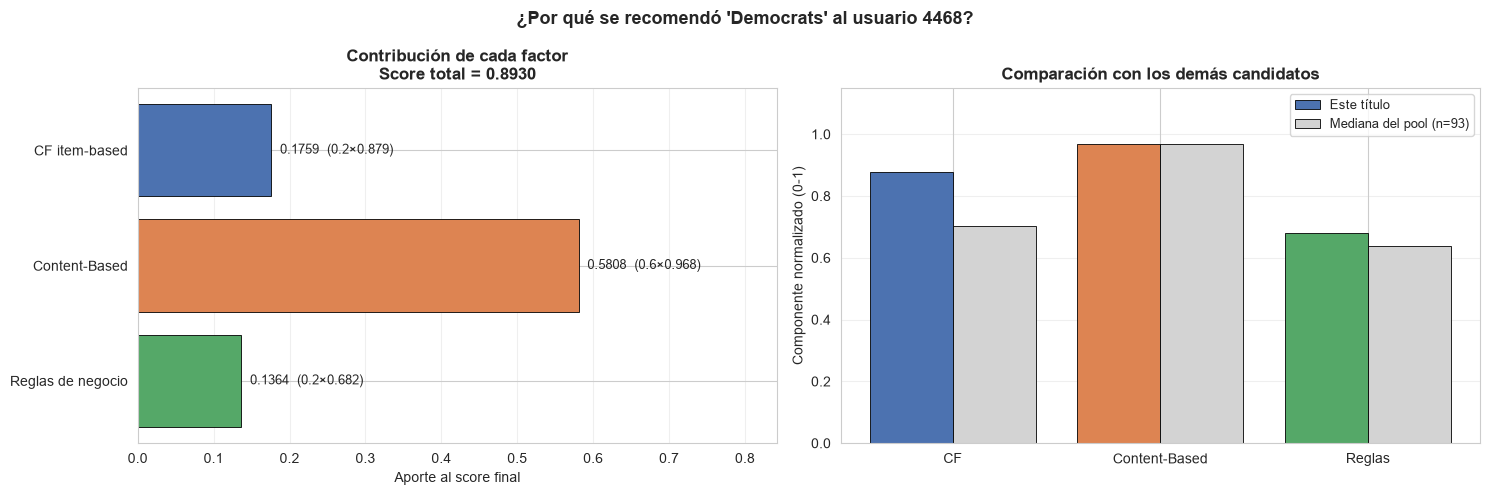



Contraste: un título que NO fue recomendado a este usuario

3%  (TV Show, 2020)
Géneros: International TV Shows, TV Dramas, TV Sci-Fi & Fantasy
Usuario 4468: John Hernandez, 47 años, UK
Perfil: 113 títulos con rating >= 3, dominado por 'Documentaries' (41 títulos)
Modo: HÍBRIDO (CF + CB + Reglas)
Posición en el ranking: fuera del pool de candidatos

Componente          Valor crudo                  Norm.   Peso   Aporte  % del score
-----------------------------------------------------------------------------------
CF item-based       3.45/5 (20 vecinos)          0.000   0.20   0.0000         0.0%
Content-Based       coseno 0.102                 0.116   0.60   0.0698        33.3%
Reglas de negocio   0.643/1                      0.700   0.20   0.1400        66.7%
-----------------------------------------------------------------------------------
SCORE FINAL                                                     0.2098       100.0%



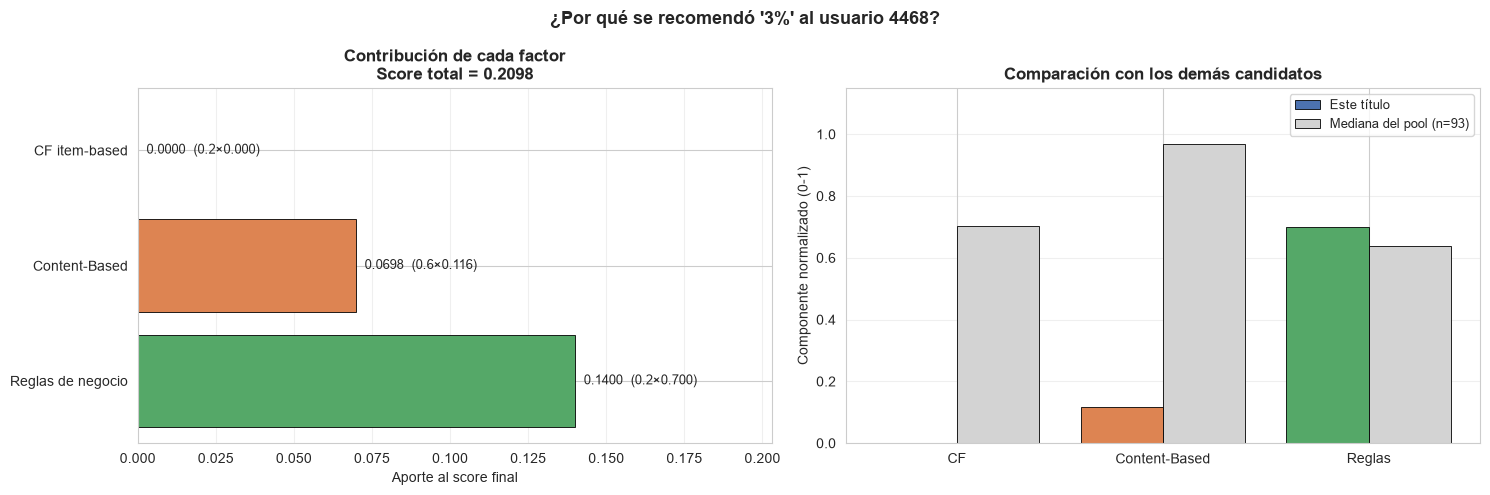

In [50]:
# ============================================================
#  ACTIVIDADES OPCIONALES — Nivel 3 (+0.5)
# Gráfico de contribución: explicar_recomendacion(show_id, user_id)
# ============================================================
# Descompone el score de una recomendación en los tres factores que lo
# generaron. Reutiliza calcular_componentes(), de modo que los números del
# gráfico son EXACTAMENTE los mismos que usa recomendar(): no hay recálculo
# paralelo ni riesgo de que la explicación difiera del modelo real.

def explicar_recomendacion(show_id, user_id, n=10, min_rating=3,
                           k=K_VECINOS, graficar=True):
    """Explica por qué se recomendó (o no) un título a un usuario.

    Devuelve un diccionario con el desglose del score y, si graficar=True,
    muestra el gráfico de contribución.

    Si el título no está en el pool de candidatos del usuario, se calculan sus
    componentes igualmente y se normalizan contra el mismo pool, para poder
    explicar también por qué NO fue recomendado.
    """
    comp, ctx = calcular_componentes(user_id, n=n, min_rating=min_rating, k=k)

    if comp.empty:
        print(f"No se pudieron generar candidatos para el usuario {user_id}.")
        return None

    if show_id not in df_catalog['show_id'].values:
        print(f"El título {show_id} no existe en el catálogo.")
        return None

    en_pool = show_id in comp.index

    if en_pool:
        fila = comp.loc[show_id]
    else:
        # Componentes crudos del título, normalizados con el min/max del pool
        preds = predecir_ratings_cf(user_id, k=k)
        cf_raw = ctx['media_u']
        n_vec = 0
        if not preds.empty and show_id in preds.index:
            valor = preds['prediccion'].get(show_id, np.nan)
            cf_raw = ctx['media_u'] if pd.isna(valor) else float(valor)
            n_vec = int(preds['n_vecinos'].get(show_id, 0))

        perfil = obtener_perfil_contenido(user_id, min_rating=min_rating)
        cb_raw = (float(cosine_similarity([perfil.values], tfidf_df.loc[[show_id]].values)[0][0])
                  if perfil is not None and show_id in tfidf_df.index else 0.0)
        rules_raw = float(calcular_score_reglas(user_id, [show_id]).iloc[0])

        def _norm_pool(valor, columna):
            mn, mx = comp[columna].min(), comp[columna].max()
            return 0.5 if mx == mn else float(np.clip((valor - mn) / (mx - mn), 0, 1))

        fila = pd.Series({
            'cf_raw': cf_raw, 'cb_raw': cb_raw, 'rules_raw': rules_raw,
            'cf_n': _norm_pool(cf_raw, 'cf_raw'),
            'cb_n': _norm_pool(cb_raw, 'cb_raw'),
            'rules_n': _norm_pool(rules_raw, 'rules_raw'),
            'n_vecinos': n_vec})

    # Pesos efectivos: en cold-start el enunciado exige usar SOLO Content-Based
    if ctx['es_cold_start']:
        pesos, modo = (0.0, 1.0, 0.0), "COLD-START (solo Content-Based)"
    else:
        pesos, modo = (ALPHA, BETA, GAMMA), "HÍBRIDO (CF + CB + Reglas)"

    aportes = np.array([pesos[0] * fila['cf_n'],
                        pesos[1] * fila['cb_n'],
                        pesos[2] * fila['rules_n']])
    score = float(aportes.sum())

    # Posición del título en el ranking del usuario
    ranking = (pesos[0] * comp['cf_n'] + pesos[1] * comp['cb_n'] +
               pesos[2] * comp['rules_n']).sort_values(ascending=False)
    posicion = int(list(ranking.index).index(show_id)) + 1 if en_pool else None

    info = df_catalog.set_index('show_id').loc[show_id]

    # --- Salida en texto ---
    print("=" * 70)
    print(f"{info['title']}  ({info['type']}, {info['release_year']})")
    print(f"Géneros: {info['genres']}")
    print("=" * 70)
    print(f"Usuario {user_id}: {ctx['nombre']}, {ctx['edad']} años, {ctx['pais']}")
    print(f"Perfil: {ctx['n_gustados']} títulos con rating >= {min_rating}, "
          f"dominado por '{ctx['genero_top']}' ({ctx['n_genero_top']} títulos)")
    print(f"Modo: {modo}")
    print(f"Posición en el ranking: "
          f"{f'#{posicion} de {len(comp)} candidatos' if en_pool else 'fuera del pool de candidatos'}\n")

    etiquetas = ['CF item-based', 'Content-Based', 'Reglas de negocio']
    crudos = [f"{fila['cf_raw']:.2f}/5 ({int(fila['n_vecinos'])} vecinos)",
              f"coseno {fila['cb_raw']:.3f}",
              f"{fila['rules_raw']:.3f}/1"]
    norm = [fila['cf_n'], fila['cb_n'], fila['rules_n']]

    print(f"{'Componente':<20}{'Valor crudo':<26}{'Norm.':>8}{'Peso':>7}{'Aporte':>9}{'% del score':>13}")
    print("-" * 83)
    for i in range(3):
        pct = aportes[i] / score * 100 if score > 0 else 0
        print(f"{etiquetas[i]:<20}{crudos[i]:<26}{norm[i]:>8.3f}{pesos[i]:>7.2f}"
              f"{aportes[i]:>9.4f}{pct:>12.1f}%")
    print("-" * 83)
    print(f"{'SCORE FINAL':<20}{'':<26}{'':>8}{'':>7}{score:>9.4f}{'100.0%':>13}\n")

    # --- Gráfico de contribución ---
    if graficar:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        colores = ['#4C72B0', '#DD8452', '#55A868']

        # Panel 1: aporte absoluto de cada factor al score
        barras = ax1.barh(etiquetas, aportes, color=colores, edgecolor='black', linewidth=0.6)
        for barra, aporte, peso, valor in zip(barras, aportes, pesos, norm):
            ax1.text(aporte + max(aportes) * 0.02, barra.get_y() + barra.get_height() / 2,
                     f"{aporte:.4f}  ({peso}×{valor:.3f})", va='center', fontsize=9)
        ax1.set_xlim(0, max(max(aportes) * 1.45, 0.01))
        ax1.set_xlabel('Aporte al score final')
        ax1.set_title(f"Contribución de cada factor\nScore total = {score:.4f}", fontweight='bold')
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)

        # Panel 2: el título frente al resto de candidatos del usuario
        medianas = [comp['cf_n'].median(), comp['cb_n'].median(), comp['rules_n'].median()]
        x = np.arange(3)
        ax2.bar(x - 0.2, norm, 0.4, label='Este título', color=colores, edgecolor='black', linewidth=0.6)
        ax2.bar(x + 0.2, medianas, 0.4, label=f'Mediana del pool (n={len(comp)})',
                color='lightgray', edgecolor='black', linewidth=0.6)
        ax2.set_xticks(x)
        ax2.set_xticklabels(['CF', 'Content-Based', 'Reglas'])
        ax2.set_ylabel('Componente normalizado (0-1)')
        ax2.set_ylim(0, 1.15)
        ax2.set_title('Comparación con los demás candidatos', fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(axis='y', alpha=0.3)

        fig.suptitle(f"¿Por qué se recomendó '{info['title']}' al usuario {user_id}?",
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return {'show_id': show_id, 'title': info['title'], 'user_id': user_id,
            'score': round(score, 4), 'posicion': posicion, 'modo': modo,
            'componentes_crudos': {'cf': float(fila['cf_raw']), 'cb': float(fila['cb_raw']),
                                   'reglas': float(fila['rules_raw'])},
            'componentes_normalizados': {'cf': float(fila['cf_n']), 'cb': float(fila['cb_n']),
                                         'reglas': float(fila['rules_n'])},
            'aportes': {'cf': float(aportes[0]), 'cb': float(aportes[1]), 'reglas': float(aportes[2])},
            'pesos': {'alpha': pesos[0], 'beta': pesos[1], 'gamma': pesos[2]}}


# --- Demostración 1: modo HÍBRIDO (usuario con historial suficiente) ---
conteo_hist = df_viewing['user_id'].value_counts()
uid_demo_exp = int(conteo_hist[conteo_hist >= 10].index[0])
recs_demo_exp = recomendar(uid_demo_exp, n=10)

print(f"Recomendación #1 para el usuario {uid_demo_exp}: {recs_demo_exp[0]['title']}\n")
_ = explicar_recomendacion(recs_demo_exp[0]['show_id'], uid_demo_exp)

# --- Demostración 2: título NO recomendado, para ver el contraste ---
no_recomendado = df_catalog.loc[df_catalog['active'] == 1, 'show_id'].iloc[0]
print("\n\nContraste: un título que NO fue recomendado a este usuario\n")
_ = explicar_recomendacion(no_recomendado, uid_demo_exp)

## Nivel 2 (+1.0, parte 1 de 2) — Evaluación completa: Recall@K, MAP y matriz de confusión

Ampliación de la evaluación del punto 5 con métricas adicionales de sistemas de
recomendación, calculadas sobre el mismo split temporal (train 2023-2024,
prueba 2025) para que los resultados sean comparables:

- **Precision@K**: proporción de aciertos entre los K títulos recomendados.
- **Recall@K**: proporción del total de títulos relevantes que se logró capturar.
- **MAP@K** (Mean Average Precision): premia que los aciertos aparezcan en las
  primeras posiciones, no solo que estén dentro del top-K.
- **F1@K**: media armónica entre precisión y recall.
- **Matriz de confusión** en K=10, con discusión de sus limitaciones en el
  contexto de recomendación.

Todas las métricas se comparan contra la línea base de popularidad para que los
valores absolutos sean interpretables.

Modelo construido (train 2023-2024): 924,883 registros | 24,949 usuarios x 7,787 títulos | 10 países

Evaluando 2,000 usuarios (top-20 por usuario)...

   250/2000 usuarios | 17s
   500/2000 usuarios | 34s
   750/2000 usuarios | 53s
   1000/2000 usuarios | 70s
   1250/2000 usuarios | 92s
   1500/2000 usuarios | 111s
   1750/2000 usuarios | 128s
   2000/2000 usuarios | 146s

Bucle completado en 146s

MÉTRICAS DE EVALUACIÓN — muestra de 2,000 usuarios (prueba 2025)
  K |            Precision@K |            Recall@K |             MAP@K |     F1@K
    |     modelo        base |    modelo      base |   modelo     base |   modelo
------------------------------------------------------------------------------
  1 |     0.0145      0.0175 |    0.0007    0.0010 |   0.0145   0.0175 |   0.0012
  3 |     0.0152      0.0167 |    0.0026    0.0026 |   0.0096   0.0105 |   0.0045
  5 |     0.0159      0.0155 |    0.0041    0.0039 |   0.0076   0.0077 |   0.0065
 10 |     0.0160      0.0159 |    0.0075   

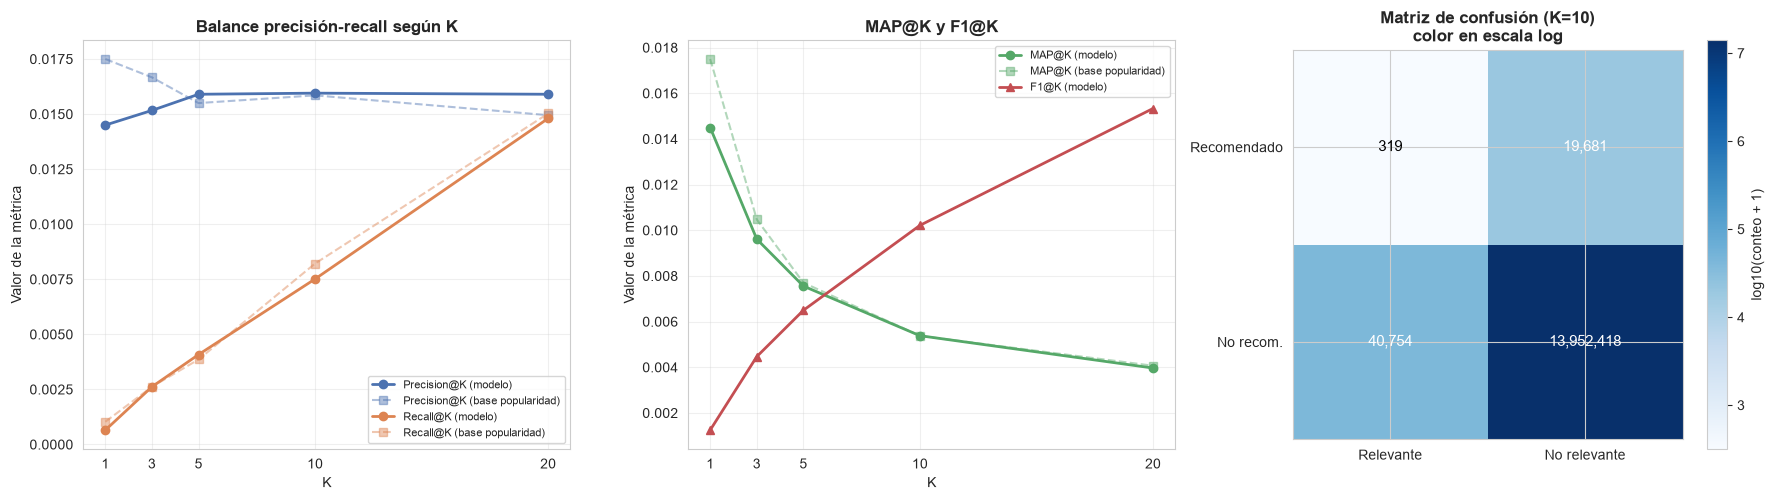

Modelo construido (historial completo): 1,502,358 registros | 25,000 usuarios x 7,787 títulos | 10 países

Modelo de producción restaurado.


In [51]:
# ============================================================
# ACTIVIDADES OPCIONALES — Nivel 2 (+1.0, parte 1 de 2)
# Precision@K, Recall@K, MAP@K, F1@K y matriz de confusión
# ============================================================
# Se ejecuta UN solo bucle guardando el top-20 de cada usuario; todas las
# métricas para los distintos K se derivan después de esas listas, sin repetir
# el cómputo pesado.

K_METRICAS = [1, 3, 5, 10, 20]
K_TOP = max(K_METRICAS)
K_CONFUSION = 10
SAMPLE_M = 2000
SEMILLA_M = 42

# --- 1. Entrenar solo con train ---
construir_modelo(train, etiqueta="(train 2023-2024)", vistos_base=None)

vistos_tr = train.groupby('user_id')['show_id'].apply(set)
rel_te = test[test['rating'] >= MIN_RATING_EVAL].groupby('user_id')['show_id'].apply(set)

relevantes_m = {}
for uid, rel in rel_te.items():
    nuevos = rel - vistos_tr.get(uid, set())
    if nuevos:
        relevantes_m[int(uid)] = nuevos

rng_m = np.random.default_rng(SEMILLA_M)
usuarios_m = np.array(list(relevantes_m.keys()))
if len(usuarios_m) > SAMPLE_M:
    usuarios_m = rng_m.choice(usuarios_m, size=SAMPLE_M, replace=False)

disponibles_m = set(df_catalog.loc[df_catalog['active'] == 1, 'show_id'])
pop_ranking_m = [s for s in train['show_id'].value_counts().index if s in disponibles_m]

print(f"\nEvaluando {len(usuarios_m):,} usuarios (top-{K_TOP} por usuario)...\n")

# --- 2. Bucle único: guardar aciertos posición por posición ---
t0 = time.time()
registros = []

for i, uid in enumerate(usuarios_m, 1):
    uid = int(uid)
    rel = relevantes_m[uid]
    vistos_u = obtener_vistos(uid)

    recs = recomendar(uid, n=K_TOP, min_rating=MIN_RATING_EVAL)
    ids_mod = [r['show_id'] for r in recs]
    ids_pop = [s for s in pop_ranking_m if s not in vistos_u][:K_TOP]

    hits_mod = np.zeros(K_TOP, dtype=bool)
    hits_pop = np.zeros(K_TOP, dtype=bool)
    for j, s in enumerate(ids_mod[:K_TOP]):
        hits_mod[j] = s in rel
    for j, s in enumerate(ids_pop[:K_TOP]):
        hits_pop[j] = s in rel

    registros.append({
        'hits_mod': hits_mod, 'hits_pop': hits_pop,
        'n_rel': len(rel), 'n_universo': len(disponibles_m - vistos_u)})

    if i % 250 == 0:
        print(f"   {i}/{len(usuarios_m)} usuarios | {time.time()-t0:.0f}s")

print(f"\nBucle completado en {time.time()-t0:.0f}s\n")


# --- 3. Cálculo de métricas ---
def average_precision(hits, n_rel, k):
    """AP@K: promedio de la precisión en cada posición donde hubo acierto.
    Se normaliza por min(n_rel, k), que es el máximo de aciertos posible."""
    aciertos, suma = 0, 0.0
    for i in range(min(k, len(hits))):
        if hits[i]:
            aciertos += 1
            suma += aciertos / (i + 1)
    denom = min(n_rel, k)
    return suma / denom if denom > 0 else 0.0


metricas = {}
for clave, campo in [('modelo', 'hits_mod'), ('popularidad', 'hits_pop')]:
    for k in K_METRICAS:
        P, R, AP = [], [], []
        for r in registros:
            h = r[campo]
            aciertos = int(h[:k].sum())
            P.append(aciertos / k)
            R.append(aciertos / r['n_rel'])
            AP.append(average_precision(h, r['n_rel'], k))
        p_m, r_m = float(np.mean(P)), float(np.mean(R))
        metricas[(clave, k)] = {
            'P': p_m, 'R': r_m, 'MAP': float(np.mean(AP)),
            'F1': (2 * p_m * r_m / (p_m + r_m)) if (p_m + r_m) > 0 else 0.0,
            'P_err': float(np.std(P, ddof=1) / np.sqrt(len(P)))}

# --- 4. Tabla de resultados ---
print("=" * 78)
print(f"MÉTRICAS DE EVALUACIÓN — muestra de {len(registros):,} usuarios (prueba 2025)")
print("=" * 78)
print(f"{'K':>3} | {'Precision@K':>22} | {'Recall@K':>19} | {'MAP@K':>17} | {'F1@K':>8}")
print(f"{'':>3} | {'modelo':>10}{'base':>12} | {'modelo':>9}{'base':>10} | {'modelo':>8}{'base':>9} | {'modelo':>8}")
print("-" * 78)
for k in K_METRICAS:
    m, b = metricas[('modelo', k)], metricas[('popularidad', k)]
    print(f"{k:>3} | {m['P']:>10.4f}{b['P']:>12.4f} | {m['R']:>9.4f}{b['R']:>10.4f} | "
          f"{m['MAP']:>8.4f}{b['MAP']:>9.4f} | {m['F1']:>8.4f}")
print("-" * 78)
print(f"Títulos relevantes por usuario: media "
      f"{np.mean([r['n_rel'] for r in registros]):.1f}")

# --- 5. Matriz de confusión en K=10 ---
TP = sum(int(r['hits_mod'][:K_CONFUSION].sum()) for r in registros)
FP = len(registros) * K_CONFUSION - TP
FN = sum(r['n_rel'] for r in registros) - TP
TN = sum(r['n_universo'] for r in registros) - TP - FP - FN

prec_c = TP / (TP + FP) if TP + FP else 0
rec_c = TP / (TP + FN) if TP + FN else 0
acc_c = (TP + TN) / (TP + TN + FP + FN)
espec = TN / (TN + FP) if TN + FP else 0

print(f"\n{'=' * 78}")
print(f"MATRIZ DE CONFUSIÓN (K={K_CONFUSION}, agregada sobre {len(registros):,} usuarios)")
print("=" * 78)
print(f"{'':<22}{'Relevante (real)':>20}{'No relevante (real)':>22}")
print(f"{'Recomendado':<22}{TP:>20,}{FP:>22,}")
print(f"{'No recomendado':<22}{FN:>20,}{TN:>22,}")
print(f"\n   Precisión   = TP/(TP+FP) = {prec_c:.4f}")
print(f"   Recall      = TP/(TP+FN) = {rec_c:.4f}")
print(f"   Especificidad             = {espec:.4f}")
print(f"   Accuracy                  = {acc_c:.4f}   <-- ENGAÑOSA, ver nota")
print("\n   NOTA: en recomendación la matriz de confusión tiene un uso limitado.")
print(f"   Los verdaderos negativos ({TN:,}) dominan el total porque el catálogo")
print(f"   tiene ~{int(np.mean([r['n_universo'] for r in registros])):,} títulos disponibles por usuario y solo se")
print(f"   recomiendan {K_CONFUSION}. Un sistema que no recomiende NADA alcanzaría una accuracy")
print("   de ~99.7%. Por eso las celdas informativas son TP, FP y FN, y las")
print("   métricas válidas son Precision@K, Recall@K y MAP@K.")

# --- 6. Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(K_METRICAS, [metricas[('modelo', k)]['P'] for k in K_METRICAS],
        'o-', label='Precision@K (modelo)', color='#4C72B0', linewidth=2)
ax.plot(K_METRICAS, [metricas[('popularidad', k)]['P'] for k in K_METRICAS],
        's--', label='Precision@K (base popularidad)', color='#4C72B0', alpha=0.45)
ax.plot(K_METRICAS, [metricas[('modelo', k)]['R'] for k in K_METRICAS],
        'o-', label='Recall@K (modelo)', color='#DD8452', linewidth=2)
ax.plot(K_METRICAS, [metricas[('popularidad', k)]['R'] for k in K_METRICAS],
        's--', label='Recall@K (base popularidad)', color='#DD8452', alpha=0.45)
ax.set_xlabel('K'); ax.set_ylabel('Valor de la métrica')
ax.set_title('Balance precisión-recall según K', fontweight='bold')
ax.set_xticks(K_METRICAS); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(K_METRICAS, [metricas[('modelo', k)]['MAP'] for k in K_METRICAS],
        'o-', label='MAP@K (modelo)', color='#55A868', linewidth=2)
ax.plot(K_METRICAS, [metricas[('popularidad', k)]['MAP'] for k in K_METRICAS],
        's--', label='MAP@K (base popularidad)', color='#55A868', alpha=0.45)
ax.plot(K_METRICAS, [metricas[('modelo', k)]['F1'] for k in K_METRICAS],
        '^-', label='F1@K (modelo)', color='#C44E52', linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('Valor de la métrica')
ax.set_title('MAP@K y F1@K', fontweight='bold')
ax.set_xticks(K_METRICAS); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
cm = np.array([[TP, FP], [FN, TN]], dtype=float)
im = ax.imshow(np.log10(cm + 1), cmap='Blues')
for (fi, ci), val in np.ndenumerate(cm):
    ax.text(ci, fi, f"{int(val):,}", ha='center', va='center', fontsize=11,
            color='white' if np.log10(val + 1) > np.log10(cm.max() + 1) * 0.6 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Relevante', 'No relevante'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Recomendado', 'No recom.'])
ax.set_title(f'Matriz de confusión (K={K_CONFUSION})\ncolor en escala log', fontweight='bold')
plt.colorbar(im, ax=ax, label='log10(conteo + 1)')

plt.tight_layout()
plt.show()

# --- 7. Restaurar el modelo de producción ---
construir_modelo(df_viewing_full, etiqueta="(historial completo)", vistos_base=df_vistos)
print("\nModelo de producción restaurado.")

## Nivel 2 (+1.0, parte 2 de 2) — Análisis de sensibilidad de `k_neighbors`

Estudio de cómo varía la precisión del sistema al cambiar el número de vecinos
más similares que el filtrado colaborativo considera para predecir un rating.

Se evalúan dos rankings por cada valor de k:

- **Ranking híbrido**: con los pesos calibrados (α, β, γ).
- **Ranking CF puro**: ordenando únicamente por la predicción colaborativa, para
  aislar el efecto de k sin que los otros componentes lo enmascaren.

Se usa el split interno (train 2023 / validación 2024), dejando el año 2025
intacto, ya que se trata de la selección de un hiperparámetro.

Modelo construido (train interno 2023): 275,048 registros | 24,099 usuarios x 7,787 títulos | 10 países

Usuarios para el análisis: 800
Valores de k a evaluar: [5, 10, 20, 50, 100]
Estimado: ~6 minutos

   k=  5 | P@10 híbrido 0.0192 | P@10 solo CF 0.0025 | vecinos usados (prom.) 1.41 | 65s
   k= 10 | P@10 híbrido 0.0191 | P@10 solo CF 0.0025 | vecinos usados (prom.) 1.46 | 136s
   k= 20 | P@10 híbrido 0.0191 | P@10 solo CF 0.0025 | vecinos usados (prom.) 1.46 | 198s
   k= 50 | P@10 híbrido 0.0191 | P@10 solo CF 0.0025 | vecinos usados (prom.) 1.46 | 261s
   k=100 | P@10 híbrido 0.0191 | P@10 solo CF 0.0025 | vecinos usados (prom.) 1.46 | 320s

ANÁLISIS DE SENSIBILIDAD DE k_neighbors (validación 2024)
    k    P@10 híbrido   P@10 solo CF   Vecinos usados   % con vecinos
------------------------------------------------------------------------
    5          0.0192         0.0025             1.41           82.2%
   10          0.0191         0.0025             1.46           82.2%
   20 

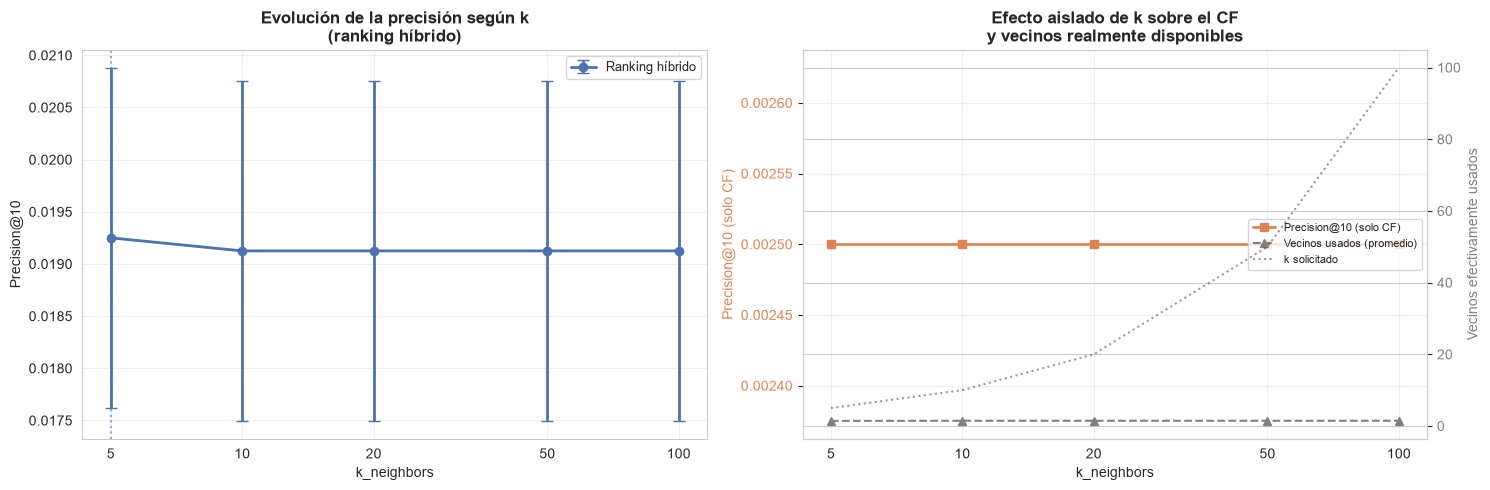

Modelo construido (historial completo): 1,502,358 registros | 25,000 usuarios x 7,787 títulos | 10 países

Modelo de producción restaurado.


In [52]:
# ============================================================
# ACTIVIDADES OPCIONALES — Nivel 2 (+1.0, parte 2 de 2)
# Análisis de sensibilidad de k_neighbors
# ============================================================

K_SENS = [5, 10, 20, 50, 100]
SAMPLE_SENS = 800
SEMILLA_SENS = 42

# --- 1. Split interno: train 2023 / validación 2024 (2025 no se toca) ---
fechas_s = df_viewing_full['watch_date']
train_s = df_viewing_full[(fechas_s >= pd.Timestamp('2023-01-01')) &
                          (fechas_s <= pd.Timestamp('2023-12-31'))]
val_s = df_viewing_full[(fechas_s >= pd.Timestamp('2024-01-01')) &
                        (fechas_s <= pd.Timestamp('2024-12-31'))]

construir_modelo(train_s, etiqueta="(train interno 2023)", vistos_base=None)

vistos_s = train_s.groupby('user_id')['show_id'].apply(set)
rel_s = val_s[val_s['rating'] >= MIN_RATING_EVAL].groupby('user_id')['show_id'].apply(set)

relevantes_s = {}
for uid, rel in rel_s.items():
    nuevos = rel - vistos_s.get(uid, set())
    if nuevos and len(vistos_s.get(uid, set())) >= 3:
        relevantes_s[int(uid)] = nuevos

rng_s = np.random.default_rng(SEMILLA_SENS)
usuarios_s = np.array(list(relevantes_s.keys()))
if len(usuarios_s) > SAMPLE_SENS:
    usuarios_s = rng_s.choice(usuarios_s, size=SAMPLE_SENS, replace=False)

print(f"\nUsuarios para el análisis: {len(usuarios_s):,}")
print(f"Valores de k a evaluar: {K_SENS}")
print(f"Estimado: ~{len(K_SENS) * len(usuarios_s) * 0.09 / 60:.0f} minutos\n")

# --- 2. Barrido sobre k ---
K_EVAL_P = 10
resultados_sens = []
t0 = time.time()

for k in K_SENS:
    p_hib, p_cf, vecinos, sim_usada = [], [], [], []

    for uid in usuarios_s:
        uid = int(uid)
        comp, ctx = calcular_componentes(uid, n=K_EVAL_P, min_rating=MIN_RATING_EVAL, k=k)
        if comp.empty or ctx['es_cold_start']:
            continue

        rel = relevantes_s[uid]
        es_rel = np.fromiter((s in rel for s in comp.index), dtype=bool, count=len(comp))

        score_hib = (ALPHA * comp['cf_n'] + BETA * comp['cb_n'] + GAMMA * comp['rules_n']).to_numpy()
        score_cf = comp['cf_n'].to_numpy()

        for score, acc in ((score_hib, p_hib), (score_cf, p_cf)):
            kk = min(K_EVAL_P, len(score))
            top = np.argpartition(-score, kk - 1)[:kk]
            acc.append(es_rel[top].sum() / K_EVAL_P)

        vecinos.append(comp['n_vecinos'].mean())
        sim_usada.append((comp['n_vecinos'] > 0).mean())

    resultados_sens.append({
        'k': k, 'p_hibrido': np.mean(p_hib), 'p_cf': np.mean(p_cf),
        'err_hib': np.std(p_hib, ddof=1) / np.sqrt(len(p_hib)),
        'vecinos_prom': np.mean(vecinos), 'cobertura': np.mean(sim_usada),
        'n_usuarios': len(p_hib)})

    r = resultados_sens[-1]
    print(f"   k={k:>3} | P@10 híbrido {r['p_hibrido']:.4f} | P@10 solo CF {r['p_cf']:.4f} | "
          f"vecinos usados (prom.) {r['vecinos_prom']:.2f} | {time.time()-t0:.0f}s")

df_sens = pd.DataFrame(resultados_sens)

# --- 3. Resultados ---
print(f"\n{'=' * 72}")
print("ANÁLISIS DE SENSIBILIDAD DE k_neighbors (validación 2024)")
print("=" * 72)
print(f"{'k':>5}{'P@10 híbrido':>16}{'P@10 solo CF':>15}{'Vecinos usados':>17}{'% con vecinos':>16}")
print("-" * 72)
for _, r in df_sens.iterrows():
    print(f"{int(r['k']):>5}{r['p_hibrido']:>16.4f}{r['p_cf']:>15.4f}"
          f"{r['vecinos_prom']:>17.2f}{r['cobertura']*100:>15.1f}%")
print("-" * 72)

k_opt_hib = int(df_sens.loc[df_sens['p_hibrido'].idxmax(), 'k'])
k_opt_cf = int(df_sens.loc[df_sens['p_cf'].idxmax(), 'k'])
rango_hib = df_sens['p_hibrido'].max() - df_sens['p_hibrido'].min()
err_medio = df_sens['err_hib'].mean()

print(f"\nk óptimo (ranking híbrido) : {k_opt_hib}   -> P@10 = {df_sens['p_hibrido'].max():.4f}")
print(f"k óptimo (ranking CF puro) : {k_opt_cf}   -> P@10 = {df_sens['p_cf'].max():.4f}")
print(f"\nVariación total en el híbrido: {rango_hib:.4f} | error estándar medio: ±{err_medio:.4f}")
print("La variación es SIGNIFICATIVA." if rango_hib > 2 * err_medio else
      "La variación NO supera el ruido estadístico: el modelo es INSENSIBLE a k.")

# --- 4. Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.errorbar(df_sens['k'], df_sens['p_hibrido'], yerr=df_sens['err_hib'],
             fmt='o-', capsize=4, linewidth=2, color='#4C72B0', label='Ranking híbrido')
ax1.axvline(k_opt_hib, ls=':', color='#4C72B0', alpha=0.6)
ax1.set_xscale('log'); ax1.set_xticks(K_SENS)
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax1.set_xlabel('k_neighbors'); ax1.set_ylabel('Precision@10')
ax1.set_title('Evolución de la precisión según k\n(ranking híbrido)', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.plot(df_sens['k'], df_sens['p_cf'], 's-', linewidth=2, color='#DD8452',
         label='Precision@10 (solo CF)')
ax2.set_xscale('log'); ax2.set_xticks(K_SENS)
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xlabel('k_neighbors'); ax2.set_ylabel('Precision@10 (solo CF)', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')

ax2b = ax2.twinx()
ax2b.plot(df_sens['k'], df_sens['vecinos_prom'], '^--', color='gray',
          label='Vecinos usados (promedio)')
ax2b.plot(df_sens['k'], df_sens['k'], ':', color='black', alpha=0.4, label='k solicitado')
ax2b.set_ylabel('Vecinos efectivamente usados', color='gray')
ax2b.tick_params(axis='y', labelcolor='gray')

lineas = ax2.get_lines() + ax2b.get_lines()
ax2.legend(lineas, [l.get_label() for l in lineas], fontsize=8, loc='center right')
ax2.set_title('Efecto aislado de k sobre el CF\ny vecinos realmente disponibles', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Restaurar el modelo de producción ---
construir_modelo(df_viewing_full, etiqueta="(historial completo)", vistos_base=df_vistos)
print("\nModelo de producción restaurado.")

In [53]:
## Se puede poner cualquier usuario para ver sus recomendaciones y explicaciones, por ejemplo:
user_id_consulta = 123
recomendaciones = recomendar(user_id_consulta, n=10)
nombre_usuario = df_users.loc[df_users['User_ID'] == user_id_consulta, 'Name'].values
nombre_usuario = nombre_usuario[0] if len(nombre_usuario) > 0 else "Usuario"
print(f"{nombre_usuario}, hoy te recomendamos esto:\n")
nombre_archivo = f"recomendaciones{user_id_consulta}.txt"
with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(f"{nombre_usuario}, hoy te recomendamos esto:\n\n")
    for r in recomendaciones:
        linea_titulo = f"{r['title']} ({r['type']}) — score: {r['score']}"
        linea_justificacion = f"  {r['justificacion']}\n"
        print(linea_titulo)
        print(linea_justificacion)
        f.write(linea_titulo + "\n")
        f.write(linea_justificacion + "\n")
print(f"Archivo exportado: {nombre_archivo}")

Katie Davis, hoy te recomendamos esto:

The Lovers and the Despot (Movie) — score: 0.8119
  Recomendado porque el perfil de contenido de tu historial (87 títulos con rating ≥ 3, 26 de ellos del género Documentaries) tiene una similitud coseno de 0.70 con los géneros de este título (Documentaries, International Movies). Este factor aporta el 71% del score final. DESGLOSE — Usuario ID 123 (Katie Davis, 80 años, UK), perfil construido con 87 títulos de rating ≥ 3, dominado por el género Documentaries (26 títulos). [CF item-based] rating estimado 3.81/5 a partir de 20 título(s) similares ya calificados, sobre una media personal de 3.56 → componente 0.801. [Content-Based] similitud coseno 0.70 con los géneros de este título (Documentaries, International Movies) → componente 0.962. [Reglas] popularidad en el país y tipo preferido: 0.42/1 → componente 0.372. Score = 0.2·0.801 + 0.6·0.962 + 0.2·0.372 = 0.8119.

Treasures from the Wreck of the Unbelievable (Movie) — score: 0.8098
  Recomendado 

El análisis de sensibilidad sobre k_neighbors (valores 5, 10, 20, 50 y 100) muestra que la Precision@10 permanece constante en 0.0191–0.0192, con una variación total de 0.0001 frente a un error estándar de ±0.0016. La causa se identifica en el número de vecinos efectivamente disponibles: con una sparsity del 99.2%, cada título cuenta en promedio con solo 2 vecinos de similitud positiva entre los ítems ya calificados por el usuario, de modo que k nunca llega a ser una restricción activa. El mismo comportamiento se observa aislando el ranking colaborativo puro (0.0025 constante), lo que descarta que el bajo aporte del componente CF se deba a una mala elección de este hiperparámetro. Se conserva k=20 por ser un valor estándar; la muestra de 800 usuarios permite descartar efectos superiores a ~0.003.